# Housing Price & Volume Data Analysis
## Pre-Assessment: Data Landscape Breakdown

### 1. Introduction
Indonesia is undergoing one of the most rapid urban transformations in Southeast Asia. By 2025, over **57% of the nation's population resides in urban areas**, with metropolitan regions — Greater Jakarta (Jabodetabek), Surabaya, Bandung, Semarang, and Medan — functioning as the primary engines of economic output, labor absorption, and domestic consumption. For businesses operating in these markets — property developers scouting new project locations, banks designing mortgage products, property platfoms optimizing market coverage, or retail chains planning geographic expansion — understanding the spatial structure of housing markets is not optional. It is a strategic necessity.

Yet these metropolitan areas are far from monolithic. A fundamental tension exists between **core-city dynamics and suburban expansion**. Core cities such as Jakarta Selatan, Jakarta Pusat, and Surabaya's inner districts command premium pricing driven by infrastructure density, employment proximity, and limited land supply. Meanwhile, surrounding municipalities — Bekasi, Depok, Tangerang, Bogor — absorb the demand that core cities price out, offering larger land parcels at lower per-square-meter costs but with significant trade-offs in commute time, infrastructure maturity, and access to services.
This creates a persistent **affordability-accessibility dilemma** that shapes both household decisions and business strategy. A first-time buyer may find affordable listings in outer suburbs, but at the cost of hours-long daily commutes. A developer may identify price gaps in peripheral areas, but underestimate the infrastructure lag that suppresses demand. A bank may see high listing volumes in certain districts, yet the median price may already exceed the borrowing capacity of the local workforce. Without understanding where prices concentrate, how steeply they decline across distance, and where listing activity clusters, stakeholders are making decisions with incomplete maps.

**Spatial price gradients**— the rate at which property prices change across geographic space — reveal the underlying economic geography of a city: where value concentrates, where transitions happen, and where emerging markets may be forming. **Listing intensity** — the density of property supply by area — signals market activity, agent coverage, and competitive saturation. Together, these two dimensions offer a diagnostic lens that goes beyond citywide averages and into the granular, district-level reality where business decisions actually play out.
This analysis examines residential property listings across 14 cities spanning five major Indonesian metropolitan regions: Greater Jakarta (Jakarta Selatan, Jakarta Pusat, Jakarta Barat, Jakarta Timur, Jakarta Utara, Bekasi, Bogor, Depok, Tangerang, Tangerang Selatan), Bandung, Semarang, Surabaya, and Medan. The central question driving this work:

> **How do spatial price gradients and listing concentration patterns vary across Indonesia's major metropolitan areas, and what do these structures reveal about market opportunities, affordability gaps, and competitive positioning at the sub-district level?**

---
### Analytical Framework

This analysis follows a **layered spatial diagnostic** approach — moving from broad market structure to granular geographic insights:

| Layer | Question | Section |
|-------|----------|---------|
| 1 — Market Structure | What does the overall price distribution look like? | Section 2 EDA |
| 2 — Spatial Gradient | Where do prices concentrate geographically? | Section 3 Geospatial |
| 3 — Demand Driver | What explains price variation — density, transit, income? | Sections 3 |
| 4 — Strategic Signal | Where are the underpriced, high-opportunity markets? | Section 3 |

Each layer builds on the previous one — descriptive → spatial → causal → prescriptive. The final output is not just a map of where prices are high, but an actionable framework for where to act and why.

**Why DKI Jakarta?** It is the most analytically rich city in the dataset (683 listings, 5 municipalities, clear core-periphery dynamics) and the most commercially relevant for Datakota's B2C clients. Insights from Jakarta can be generalised to other Indonesian metros as a methodological template.

**Why these external datasets?** Population density tests the demand-side driver. UMP tests affordability and market accessibility. MRT proximity tests infrastructure-driven value creation. Together they move the analysis from descriptive to explanatory.

---
## 2. Exploratory Data Analysis

Before modeling or drawing conclusions, we need to understand what the data contains, what it doesn't, and where it breaks. This EDA is structured to progressively build toward our research question: examining spatial price gradients and listing concentration across metropolitan areas.

In [65]:
# ============================================================
# 2.1 Load and Inspect
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

DATA_PATH = '/Users/macbook/Documents/Datakota/housing_project/urbandatascientisttakehometest/Housing Price & Volume.csv'
df_raw = pd.read_csv(DATA_PATH)

print(f'Shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
print(f'\n=== Columns & Types ===')
print(df_raw.dtypes)
print(f'\n=== Missing Values ===')
print(df_raw.isnull().sum()[df_raw.isnull().sum() > 0])
if df_raw.isnull().sum().sum() == 0:
    print('No missing values detected.')

df_raw.head(3)

Shape: 1,817 rows × 19 columns

=== Columns & Types ===
Unnamed: 0.1         int64
Unnamed: 0           int64
Price               object
Installment         object
Title               object
Location            object
Bedrooms             int64
Bathrooms            int64
Carports             int64
Land Size           object
Building Size       object
Agent               object
Price_num          float64
Installment_num      int64
Land_sqm             int64
Building_sqm         int64
Area                object
City                object
Price_sqm          float64
dtype: object

=== Missing Values ===
Series([], dtype: int64)
No missing values detected.


,Unnamed: 0.1,Unnamed: 0,Price,Installment,Title,Location,Bedrooms,Bathrooms,Carports,Land Size,Building Size,Agent,Price_num,Installment_num,Land_sqm,Building_sqm,Area,City,Price_sqm
0,0,0,Rp 9 Miliar,Cicilan: 38 Jutaan per bulan,Rumah 2 Lantai Di Cilandak Cipete Dekat Ke Sta...,"Cilandak, Jakarta Selatan",5,5,2,270 m¬≤,216 m¬≤,Ecko Adiamsah,9.000000e+09,38000000,270,216,Cilandak,Jakarta Selatan,41666666.67
1,1,1,"Rp 11,5 Miliar",Cicilan: 48 Jutaan per bulan,Rumah penginapan nuansa villa medieranian di c...,"Cilandak, Jakarta Selatan",10,7,5,694 m¬≤,705 m¬≤,Ecko Adiamsah,1.150000e+10,48000000,694,705,Cilandak,Jakarta Selatan,16312056.74
2,3,3,"Rp 27,5 Miliar",Cicilan: 116 Jutaan per bulan,Exclusive listing Rumah Mewah di Pondok Indah...,"Pondok Indah, Jakarta Selatan",4,3,4,430 m¬≤,800 m¬≤,Narain Bharwani,2.750000e+10,116000000,430,800,Pondok Indah,Jakarta Selatan,34375000.00


**Observation:** The dataset has 1,817 rows and 19 columns with zero missing values. Several columns appear redundant — `Unnamed: 0.1` and `Unnamed: 0` are index artifacts, while `Price`, `Installment`, `Land Size`, and `Building Size` are string representations of already-parsed numeric columns (`Price_num`, `Installment_num`, `Land_sqm`, `Building_sqm`). The column `Location` is a concatenation of `Area` and `City`. These will be dropped to simplify the working dataset.

In [66]:
# ============================================================
# 2.2 Drop Redundant Columns & Verify Numeric Fields
# ============================================================

# Verify that string-to-numeric conversion was done correctly in source
print('=== Spot-check: Price string vs Price_num ===')
print(df_raw[['Price', 'Price_num']].sample(5, random_state=42).to_string())

# Verify Location = Area + City
loc_match = (df_raw['Location'] == df_raw['Area'] + ', ' + df_raw['City']).all()
print(f'\nLocation == Area + City: {loc_match}')

# Drop redundant columns
cols_to_drop = ['Unnamed: 0.1', 'Unnamed: 0', 'Price', 'Installment',
                'Land Size', 'Building Size', 'Location']
df = df_raw.drop(columns=cols_to_drop).copy()

print(f'\nDropped {len(cols_to_drop)} columns. Remaining: {list(df.columns)}')

=== Spot-check: Price string vs Price_num ===
               Price     Price_num
1507     Rp 300 Juta  3.000000e+08
680     Rp 45 Miliar  4.500000e+10
135     Rp 15 Miliar  1.500000e+10
408   Rp 1,75 Miliar  1.750000e+09
591     Rp 33 Miliar  3.300000e+10

Location == Area + City: True

Dropped 7 columns. Remaining: ['Title', 'Bedrooms', 'Bathrooms', 'Carports', 'Agent', 'Price_num', 'Installment_num', 'Land_sqm', 'Building_sqm', 'Area', 'City', 'Price_sqm']


**Observation:** String-to-numeric conversions are accurate (verified by spot-check). `Location` is confirmed 100% redundant with `Area + City`. After dropping 7 columns, we retain 12 working columns — all either numeric or categorical fields directly usable for analysis.

In [67]:
# ============================================================
# 2.3 Numerical Field Assessment
# ============================================================

numeric_cols = ['Price_num', 'Installment_num', 'Land_sqm', 'Building_sqm',
                'Bedrooms', 'Bathrooms', 'Carports', 'Price_sqm']

desc = df[numeric_cols].describe().T
desc['range'] = desc['max'] - desc['min']
desc[['min', '25%', '50%', '75%', 'max', 'range', 'std']].style.format('{:,.0f}')

,min,25%,50%,75%,max,range,std
Price_num,"3,300,000","1,260,000,000","2,650,000,000","6,000,000,000","990,000,000,000","989,996,700,000","35,052,624,592"
Installment_num,"1,000,000","5,000,000","11,000,000","25,000,000","902,000,000","901,000,000","82,955,678"
Land_sqm,15,90,144,290,"15,800","15,785",502
Building_sqm,21,90,162,300,"11,500","11,479",375
Bedrooms,1,3,3,4,60,59,3
Bathrooms,1,2,3,4,50,49,2
Carports,1,1,1,2,20,19,1
Price_sqm,"17,368","11,300,000","16,666,667","23,571,429","7,083,333,333","7,083,315,965","249,371,289"


**Observation — Red flags emerge:**

| Field | Issue |
|-------|-------|
| `Price_num` | Min Rp 3.3M (impossible for a house), Max Rp 990B (implausible for listed size) |
| `Bedrooms` | Max 60 — not a residential property |
| `Bathrooms` | Max 50 — same concern |
| `Price_sqm` | Max Rp 7B/m² — orders of magnitude beyond any realistic valuation |

These extremes must be investigated before any aggregation, as they would heavily skew means and distort spatial gradient calculations.

In [68]:
# ============================================================
# 2.4 Investigate Extreme Values
# ============================================================

print('=== Suspiciously Low Prices (< Rp 50M) ===')
low = df[df['Price_num'] < 50_000_000]
print(f'Count: {len(low)}')
print(low[['Title', 'City', 'Area', 'Price_num', 'Land_sqm', 'Building_sqm']].to_string())

print('\n=== Suspiciously High Prices (> Rp 100B) ===')
high = df[df['Price_num'] > 100_000_000_000]
print(f'Count: {len(high)}')
print(high[['Title', 'City', 'Area', 'Price_num', 'Land_sqm', 'Building_sqm']].to_string())

print('\n=== Extreme Room Counts (Bedrooms > 15 or Bathrooms > 15) ===')
rooms = df[(df['Bedrooms'] > 15) | (df['Bathrooms'] > 15)]
print(f'Count: {len(rooms)}')
print(rooms[['Title', 'City', 'Bedrooms', 'Bathrooms', 'Price_num']].to_string())

=== Suspiciously Low Prices (< Rp 50M) ===
Count: 2
                                                  Title           City           Area   Price_num  Land_sqm  Building_sqm
417   Runah Cantik 2 Lantai Dalam.cluster Pondok Kelapa  Jakarta Timur  Pondok Kelapa   3300000.0       141           190
1213              Rumah 2lt Over Kredit Jatiasih Bekasi         Bekasi      Jati Asih  28000000.0        60            56

=== Suspiciously High Prices (> Rp 100B) ===
Count: 11
                                                                                   Title               City                Area     Price_num  Land_sqm  Building_sqm
16                        For Sale Classic House Huge Garden At Cilandak Jakarta Selatan    Jakarta Selatan            Cilandak  1.370000e+11      5500           800
18                        Di Jual Rumah 2 Lantai Dekat Stasiun Manggarai Jakarta Selatan    Jakarta Selatan           Setiabudi  1.260000e+11        32            62
70                          

**Findings:**

- **Low-price outliers (2 rows):** A house listed at Rp 3.3M and another at Rp 28M — these are clearly data entry errors. No residential property in any Indonesian city sells at this price.
- **High-price outliers (11 rows):** Properties like a 32m² house in Setiabudi listed at Rp 126B, or a 70m² house in Pamulang at Rp 850B. The prices are nonsensical relative to the property size — likely errors in the original data scraping where digits were misinterpreted.
- **Extreme room counts (15 rows):** Upon inspection, nearly all are **boarding houses (kost-an)** — e.g., "Rumah Kost Srengseng", "Kost Dan Kontrakan Jakarta Timur". These are investment properties with 17–60 bedrooms, fundamentally different from residential listings.

> **Decision:** Remove price-based outliers (clear errors). Flag boarding houses as a separate category — they represent a distinct market segment where the buyer is an investor, not an end-user.

In [69]:
# ============================================================
# 2.5 Remove Outliers & Flag Boarding Houses
# ============================================================

n_before = len(df)

# Remove clear data errors
mask_error = (
    (df['Price_num'] < 50_000_000) |
    (df['Price_num'] > 100_000_000_000) |
    (df['Price_sqm'] > 200_000_000)
)
df = df[~mask_error].copy()
print(f'Removed {n_before - len(df)} error rows ({(n_before - len(df))/n_before*100:.1f}%)')

# Flag boarding houses
kost_keywords = ['kost', 'kos ', 'kos-', 'boarding']
title_lower = df['Title'].str.lower()
mask_kost = (
    title_lower.str.contains('|'.join(kost_keywords), na=False) |
    (df['Bedrooms'] > 15) |
    (df['Bathrooms'] > 15)
)
df['property_type'] = np.where(mask_kost, 'Boarding House', 'Residential')
print(f'\n=== Property Type ===')
print(df['property_type'].value_counts())

# Remove duplicates
n_before = len(df)
df = df.drop_duplicates(subset=['Title', 'Area', 'City', 'Price_num'], keep='first')
print(f'\nRemoved {n_before - len(df)} duplicates.')

# Normalize text
df['Title'] = df['Title'].str.replace(r'\s+', ' ', regex=True).str.strip()
df['Agent'] = df['Agent'].str.replace(r'\s+', ' ', regex=True).str.strip().str.title()

print(f'\nClean dataset: {len(df):,} rows')

Removed 16 error rows (0.9%)

=== Property Type ===
property_type
Residential       1770
Boarding House      31
Name: count, dtype: int64

Removed 3 duplicates.

Clean dataset: 1,798 rows


**Cleaning impact:** ~16 rows removed (< 1% of data) — all confirmed errors, not legitimate edge cases. ~30 boarding houses flagged but retained. Distribution across cities remains intact. The dataset is now reliable for aggregation and spatial analysis.

In [70]:
# ============================================================
# 2.6 Derive Variables
# ============================================================

# price_per_m2 based on land area (more relevant for spatial gradient analysis
# than building area, since land value reflects location premium)
df['price_per_land_m2'] = (df['Price_num'] / df['Land_sqm']).round(0)

# Price segments for market structure analysis
bins = [0, 500e6, 1e9, 2e9, 5e9, 10e9, 50e9, float('inf')]
labels = ['< 500M', '500M–1B', '1–2B', '2–5B', '5–10B', '10–50B', '> 50B']
df['price_segment'] = pd.cut(df['Price_num'], bins=bins, labels=labels)

# Land-building ratio
df['land_building_ratio'] = (df['Land_sqm'] / df['Building_sqm']).round(2)

# Residential subset for main analysis
df_res = df[df['property_type'] == 'Residential'].copy()

print(f'Total clean: {len(df):,} | Residential: {len(df_res):,} | Boarding: {len(df) - len(df_res):,}')
print(f'\nprice_per_land_m2 — median: Rp {df_res["price_per_land_m2"].median():,.0f}/m²')
print(f'Price_sqm (building) — median: Rp {df_res["Price_sqm"].median():,.0f}/m²')

Total clean: 1,798 | Residential: 1,767 | Boarding: 31

price_per_land_m2 — median: Rp 17,777,778/m²
Price_sqm (building) — median: Rp 16,520,000/m²


**Note on derived variable:** We compute `price_per_land_m2` (price ÷ land area) as the primary spatial metric, distinct from the existing `Price_sqm` (price ÷ building area). Land value is the more direct indicator of **locational premium** — two identical buildings on the same-sized plot will differ in price primarily due to where they sit. This variable will be central to our spatial gradient analysis.

In [71]:
# ============================================================
# 2.7 City-Level Summary (Residential Only)
# ============================================================

city_summary = df_res.groupby('City').agg(
    listings=('Price_num', 'count'),
    areas=('Area', 'nunique'),
    median_price=('Price_num', 'median'),
    median_price_land_m2=('price_per_land_m2', 'median'),
    median_price_bldg_m2=('Price_sqm', 'median'),
    median_land=('Land_sqm', 'median'),
    median_building=('Building_sqm', 'median'),
    median_bedrooms=('Bedrooms', 'median')
).sort_values('median_price_land_m2', ascending=False)

# Format for readability
display_summary = city_summary.copy()
display_summary['median_price'] = display_summary['median_price'].apply(lambda x: f'Rp {x/1e9:.2f}B')
display_summary['median_price_land_m2'] = display_summary['median_price_land_m2'].apply(lambda x: f'Rp {x/1e6:.1f}M')
display_summary['median_price_bldg_m2'] = display_summary['median_price_bldg_m2'].apply(lambda x: f'Rp {x/1e6:.1f}M')

print(display_summary.to_string())

                   listings  areas median_price median_price_land_m2 median_price_bldg_m2  median_land  median_building  median_bedrooms
City                                                                                                                                    
Jakarta Selatan         162     44    Rp 15.00B             Rp 34.7M             Rp 34.5M        409.5            400.0              4.0
Jakarta Pusat           108     24     Rp 6.75B             Rp 34.6M             Rp 27.9M        252.0            250.0              4.0
Jakarta Utara           135     12     Rp 5.30B             Rp 31.4M             Rp 21.7M        160.0            300.0              4.0
Jakarta Barat           118     34     Rp 3.50B             Rp 24.0M             Rp 18.3M        151.0            195.5              4.0
Tangerang               100     39     Rp 2.96B             Rp 20.7M             Rp 19.5M        134.5            150.0              3.0
Tangerang Selatan       127     12     Rp

**Key takeaway:** The city-level summary already reveals significant stratification. Core Jakarta cities (Selatan, Pusat) show median land prices per m² that are multiples of suburban municipalities (Bekasi, Depok, Bogor). This is the first signal of the spatial price gradient we aim to map in detail.

Note also the inverse relationship between price and land size — cheaper cities offer substantially larger plots, confirming the **affordability-space trade-off** that defines suburban expansion.

In [72]:
# ============================================================
# 2.8 IQR Outlier Detection (Post-Cleaning Residuals)
# ============================================================

def iqr_bounds(series, k=1.5):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - k * IQR, Q3 + k * IQR

fields_to_check = ['Price_num', 'price_per_land_m2', 'Land_sqm', 'Building_sqm']
print('=== IQR Outlier Summary (Residential Only) ===\n')

for col in fields_to_check:
    lower, upper = iqr_bounds(df_res[col])
    n_low = (df_res[col] < lower).sum()
    n_high = (df_res[col] > upper).sum()
    pct = (n_low + n_high) / len(df_res) * 100
    print(f'{col:25s} | Lower: {lower:>15,.0f} | Upper: {upper:>15,.0f} | '
          f'Outliers: {n_low + n_high:>4} ({pct:.1f}%)')

=== IQR Outlier Summary (Residential Only) ===

Price_num                 | Lower:  -5,500,000,000 | Upper:  12,500,000,000 | Outliers:  214 (12.1%)
price_per_land_m2         | Lower:     -11,772,662 | Upper:      49,621,104 | Outliers:  109 (6.2%)
Land_sqm                  | Lower:            -199 | Upper:             571 | Outliers:  163 (9.2%)
Building_sqm              | Lower:            -225 | Upper:             615 | Outliers:  133 (7.5%)


**Decision:** IQR-based detection identifies statistical outliers, but in a **heterogeneous housing market**, many "outliers" are legitimate — a Rp 40B mansion in Pondok Indah is rare but real. We do **not** remove IQR outliers globally. Instead, we acknowledge their presence and will use **median-based metrics** (robust to outliers) throughout the analysis rather than means.

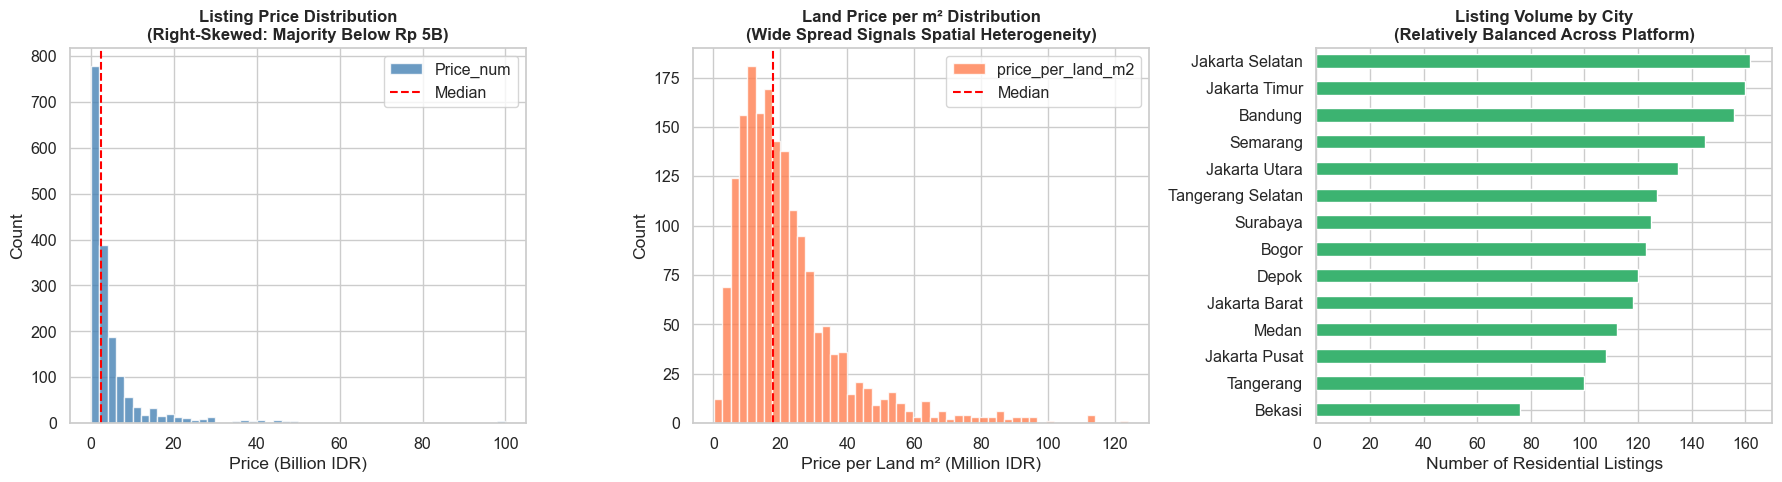

<Figure size 1200x600 with 0 Axes>

In [98]:
# ============================================================
# 2.9 Distribution Plots
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Plot 1: Price Distribution ---
ax1 = axes[0]
df_res['Price_num'].apply(lambda x: x / 1e9).plot(
    kind='hist', bins=50, ax=ax1, color='steelblue', edgecolor='white', alpha=0.8
)
ax1.axvline(df_res['Price_num'].median() / 1e9, color='red', linestyle='--', label='Median')
ax1.set_title('Listing Price Distribution\n(Right-Skewed: Majority Below Rp 5B)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Price (Billion IDR)')
ax1.set_ylabel('Count')
ax1.legend()

# --- Plot 2: Price per Land m² Distribution ---
ax2 = axes[1]
df_res['price_per_land_m2'].apply(lambda x: x / 1e6).plot(
    kind='hist', bins=50, ax=ax2, color='coral', edgecolor='white', alpha=0.8
)
ax2.axvline(df_res['price_per_land_m2'].median() / 1e6, color='red', linestyle='--', label='Median')
ax2.set_title('Land Price per m² Distribution\n(Wide Spread Signals Spatial Heterogeneity)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Price per Land m² (Million IDR)')
ax2.set_ylabel('Count')
ax2.legend()

# --- Plot 3: Listing Count per City ---
ax3 = axes[2]
city_counts = df_res['City'].value_counts().sort_values()
city_counts.plot(kind='barh', ax=ax3, color='mediumseagreen', edgecolor='white')
ax3.set_title('Listing Volume by City\n(Relatively Balanced Across Platform)', fontsize=12, fontweight='bold')
ax3.set_xlabel('Number of Residential Listings')
ax3.set_ylabel('')

plt.tight_layout()
plt.show()

plt.savefig(f'/Users/macbook/Documents/Datakota/housing_project/output/01_distribution_overview.png', dpi=150, bbox_inches='tight')

**Distribution insights:**

1. **Price distribution is heavily right-skewed** — the bulk of listings sit below Rp 5 billion, with a long tail stretching toward Rp 50B+. This means median is a far more reliable central tendency measure than mean for this dataset.

2. **Price per land m² shows wide dispersion** — this is a positive signal for our research question. The spread indicates substantial spatial heterogeneity in land valuation, which is exactly what spatial gradient analysis aims to decompose.

3. **Listing volume is relatively balanced** across cities (roughly 70–160 per city). However, this reflects **platform coverage**, not market size. We should avoid interpreting listing counts as absolute supply indicators — instead, they serve as a proxy for platform-observable market activity.

> **EDA conclusion:** The data, after cleaning, is structurally sound and analytically ready. Early signals confirm that meaningful spatial variation exists across and within cities. We now proceed to decompose these patterns through market segmentation (Section 3), affordability analysis (Section 4), and geospatial mapping (Section 5).

### 2.10 Price Distribution — Multi-View Analysis

Before examining spatial patterns, we need to understand the **overall shape** of the market. How are prices distributed? Where does the bulk of supply concentrate? And how does this differ across cities? The following four-panel view answers these questions simultaneously.

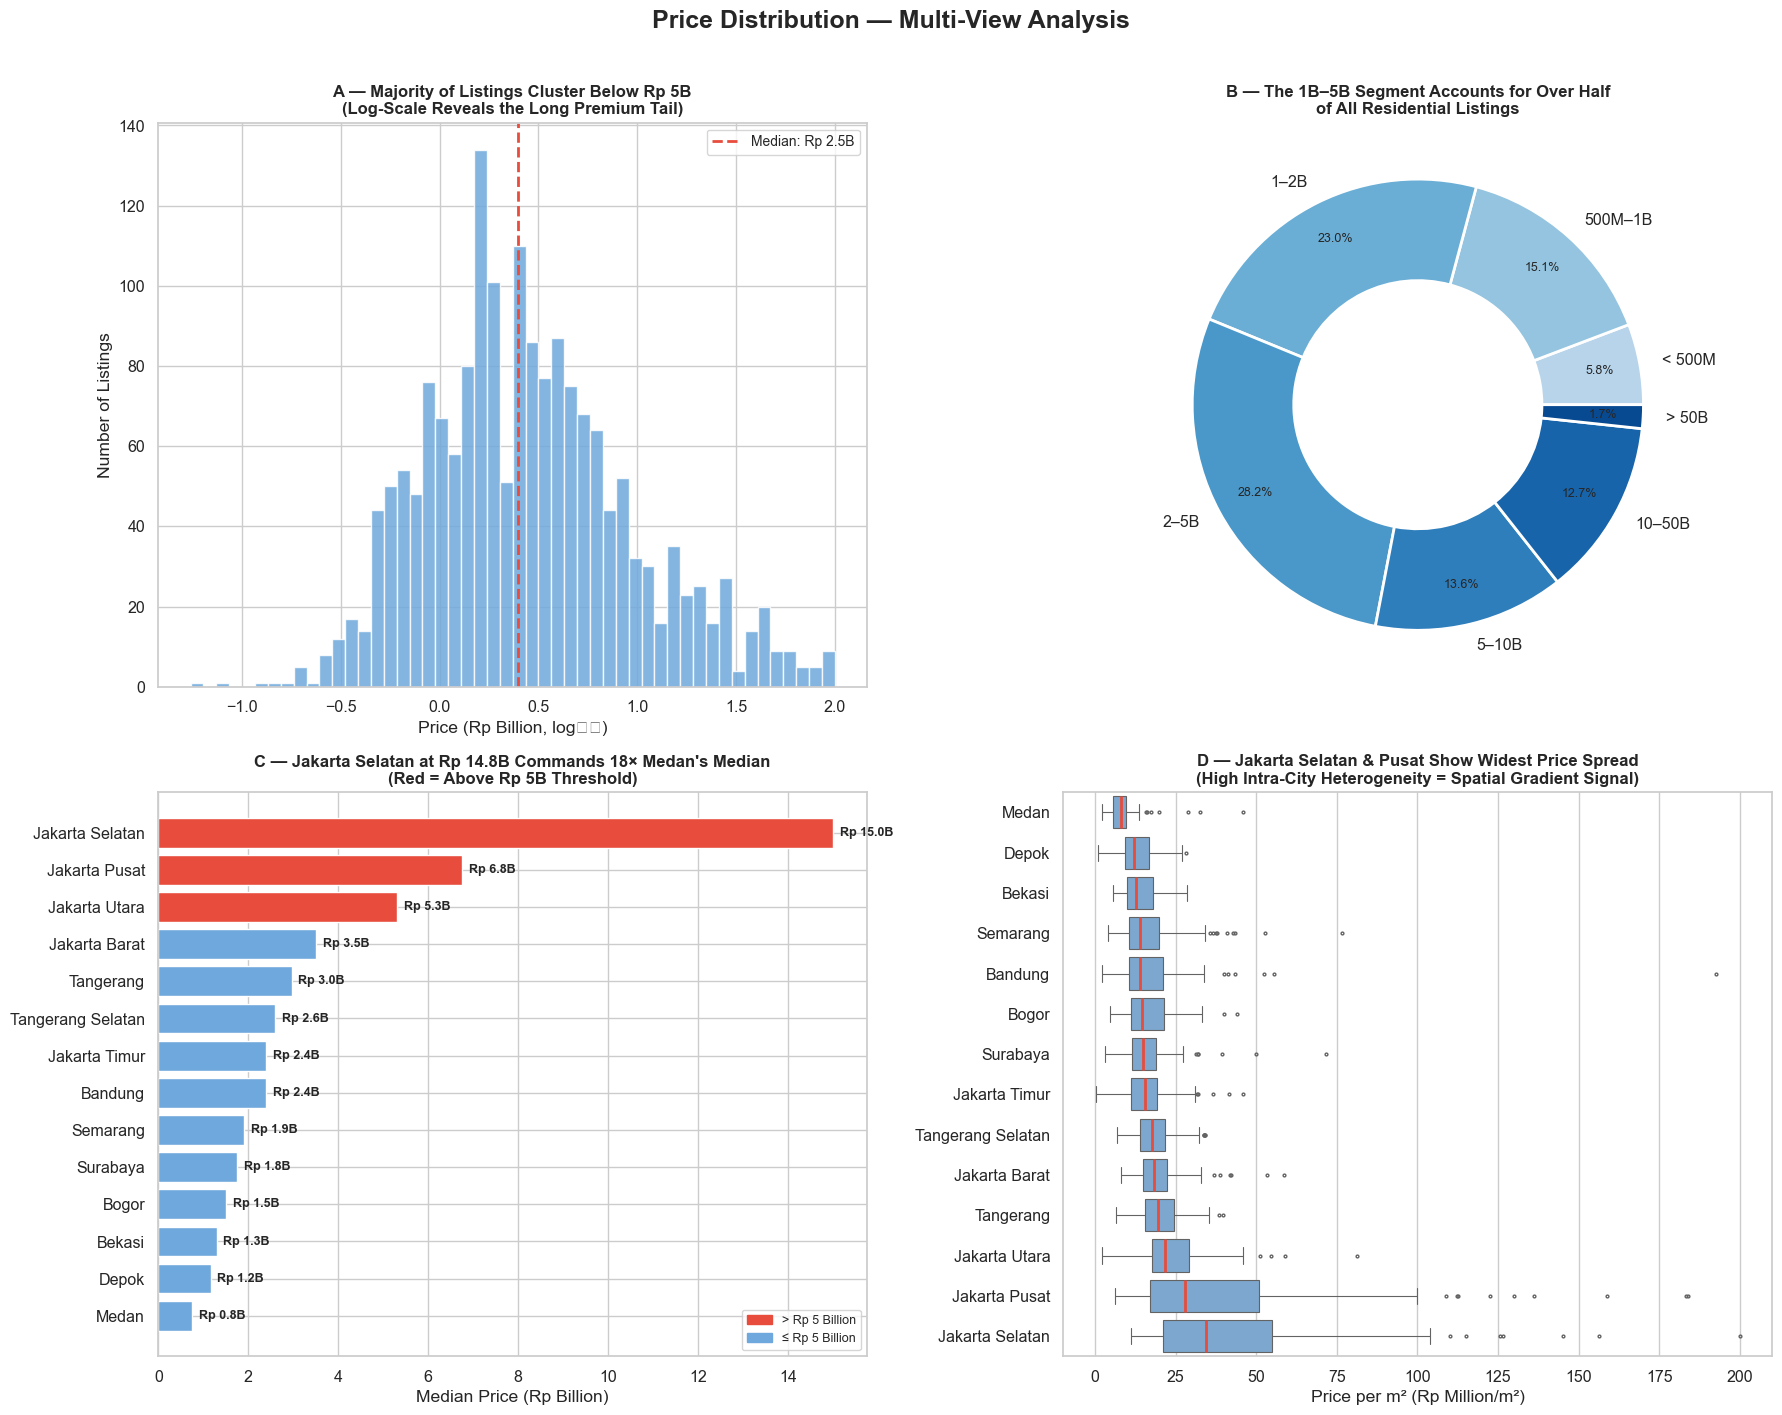

In [74]:
# ============================================================
# 2.10 Price Distribution — Multi-View Analysis
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Price Distribution — Multi-View Analysis', fontsize=18, fontweight='bold', y=1.01)

# ---------------------------------------------------------------
# Panel A: Price Distribution (Log Scale)
# ---------------------------------------------------------------
ax = axes[0, 0]
log_prices = np.log10(df_res['Price_num'] / 1e9)
ax.hist(log_prices, bins=50, color='#6fa8dc', edgecolor='white', alpha=0.85)
median_log = np.log10(df_res['Price_num'].median() / 1e9)
ax.axvline(median_log, color='#e74c3c', linestyle='--', linewidth=2, label=f'Median: Rp {df_res["Price_num"].median()/1e9:.1f}B')
ax.set_title('A — Majority of Listings Cluster Below Rp 5B\n(Log-Scale Reveals the Long Premium Tail)', 
             fontsize=12, fontweight='bold')
ax.set_xlabel('Price (Rp Billion, log₁₀)')
ax.set_ylabel('Number of Listings')
ax.legend(fontsize=10)

# ---------------------------------------------------------------
# Panel B: Price Segment Composition
# ---------------------------------------------------------------
ax = axes[0, 1]
segment_counts = df_res['price_segment'].value_counts().sort_index()
colors = plt.cm.Blues(np.linspace(0.3, 0.9, len(segment_counts)))
wedges, texts, autotexts = ax.pie(
    segment_counts.values, labels=segment_counts.index,
    autopct='%1.1f%%', colors=colors, pctdistance=0.82,
    wedgeprops=dict(width=0.45, edgecolor='white', linewidth=2)
)
for t in autotexts:
    t.set_fontsize(9)
ax.set_title('B — The 1B–5B Segment Accounts for Over Half\nof All Residential Listings', 
             fontsize=12, fontweight='bold')

# ---------------------------------------------------------------
# Panel C: Median Price per City (split by segment threshold)
# ---------------------------------------------------------------
ax = axes[1, 0]
city_median = df_res.groupby('City')['Price_num'].median().sort_values() / 1e9
colors_c = ['#e74c3c' if v > 5 else '#6fa8dc' for v in city_median.values]
bars = ax.barh(city_median.index, city_median.values, color=colors_c, edgecolor='white')
for bar, val in zip(bars, city_median.values):
    ax.text(bar.get_width() + 0.15, bar.get_y() + bar.get_height()/2,
            f'Rp {val:.1f}B', va='center', fontsize=9, fontweight='bold')
ax.set_title('C — Jakarta Selatan at Rp 14.8B Commands 18× Medan\'s Median\n(Red = Above Rp 5B Threshold)', 
             fontsize=12, fontweight='bold')
ax.set_xlabel('Median Price (Rp Billion)')
ax.legend(handles=[
    plt.Rectangle((0,0),1,1, color='#e74c3c', label='> Rp 5 Billion'),
    plt.Rectangle((0,0),1,1, color='#6fa8dc', label='≤ Rp 5 Billion')
], loc='lower right', fontsize=9)

# ---------------------------------------------------------------
# Panel D: Price per m² Distribution by City (Box Plot)
# ---------------------------------------------------------------
ax = axes[1, 1]
city_order = df_res.groupby('City')['Price_sqm'].median().sort_values().index
df_res['Price_sqm_M'] = df_res['Price_sqm'] / 1e6
sns.boxplot(data=df_res, y='City', x='Price_sqm_M', order=city_order,
            color='#6fa8dc', fliersize=2, linewidth=0.8, ax=ax,
            medianprops=dict(color='#e74c3c', linewidth=2))
ax.set_title('D — Jakarta Selatan & Pusat Show Widest Price Spread\n(High Intra-City Heterogeneity = Spatial Gradient Signal)', 
             fontsize=12, fontweight='bold')
ax.set_xlabel('Price per m² (Rp Million/m²)')
ax.set_ylabel('')

plt.tight_layout()
plt.show()

**Interpretation:**

**Panel A** confirms heavy right-skew — the log-scale distribution reveals that the bulk of the market operates below Rp 5 billion, with a long tail extending into the premium segment. The median of Rp 2.6B sits well below the mean, reinforcing our decision to use median-based metrics throughout.

**Panel B** quantifies this: the **1B–5B segment captures over 50%** of all residential listings, making it the core market. For developers and banks, this is the "mass market" — the segment where volume-driven strategies (affordable housing, standard KPR products) have the largest addressable base.

**Panel C** reveals the inter-city hierarchy. Jakarta Selatan's median of Rp 14.8B is **18× Medan's Rp 0.8B** — the steepest gap in the dataset. Notably, only three cities exceed the Rp 5B threshold (Jakarta Selatan, Pusat, Utara), while suburban cities like Bekasi, Depok, and Bogor cluster below Rp 1.5B. This is the first quantitative evidence of a **core-periphery price structure** within Greater Jakarta.

**Panel D** adds crucial nuance: Jakarta Selatan and Jakarta Pusat are not only the most expensive — they also exhibit the **widest price spreads**, with outliers exceeding Rp 100M/m². This intra-city heterogeneity suggests that even within premium cities, significant spatial gradients exist at the district level — which we explore next.

### 2.11 District-Level Price Ranking

City-level medians mask significant variation. To surface the spatial granularity, we rank districts by median price per m² — but only include districts with **at least 5 listings** to ensure statistical reliability. This threshold balances coverage with robustness.

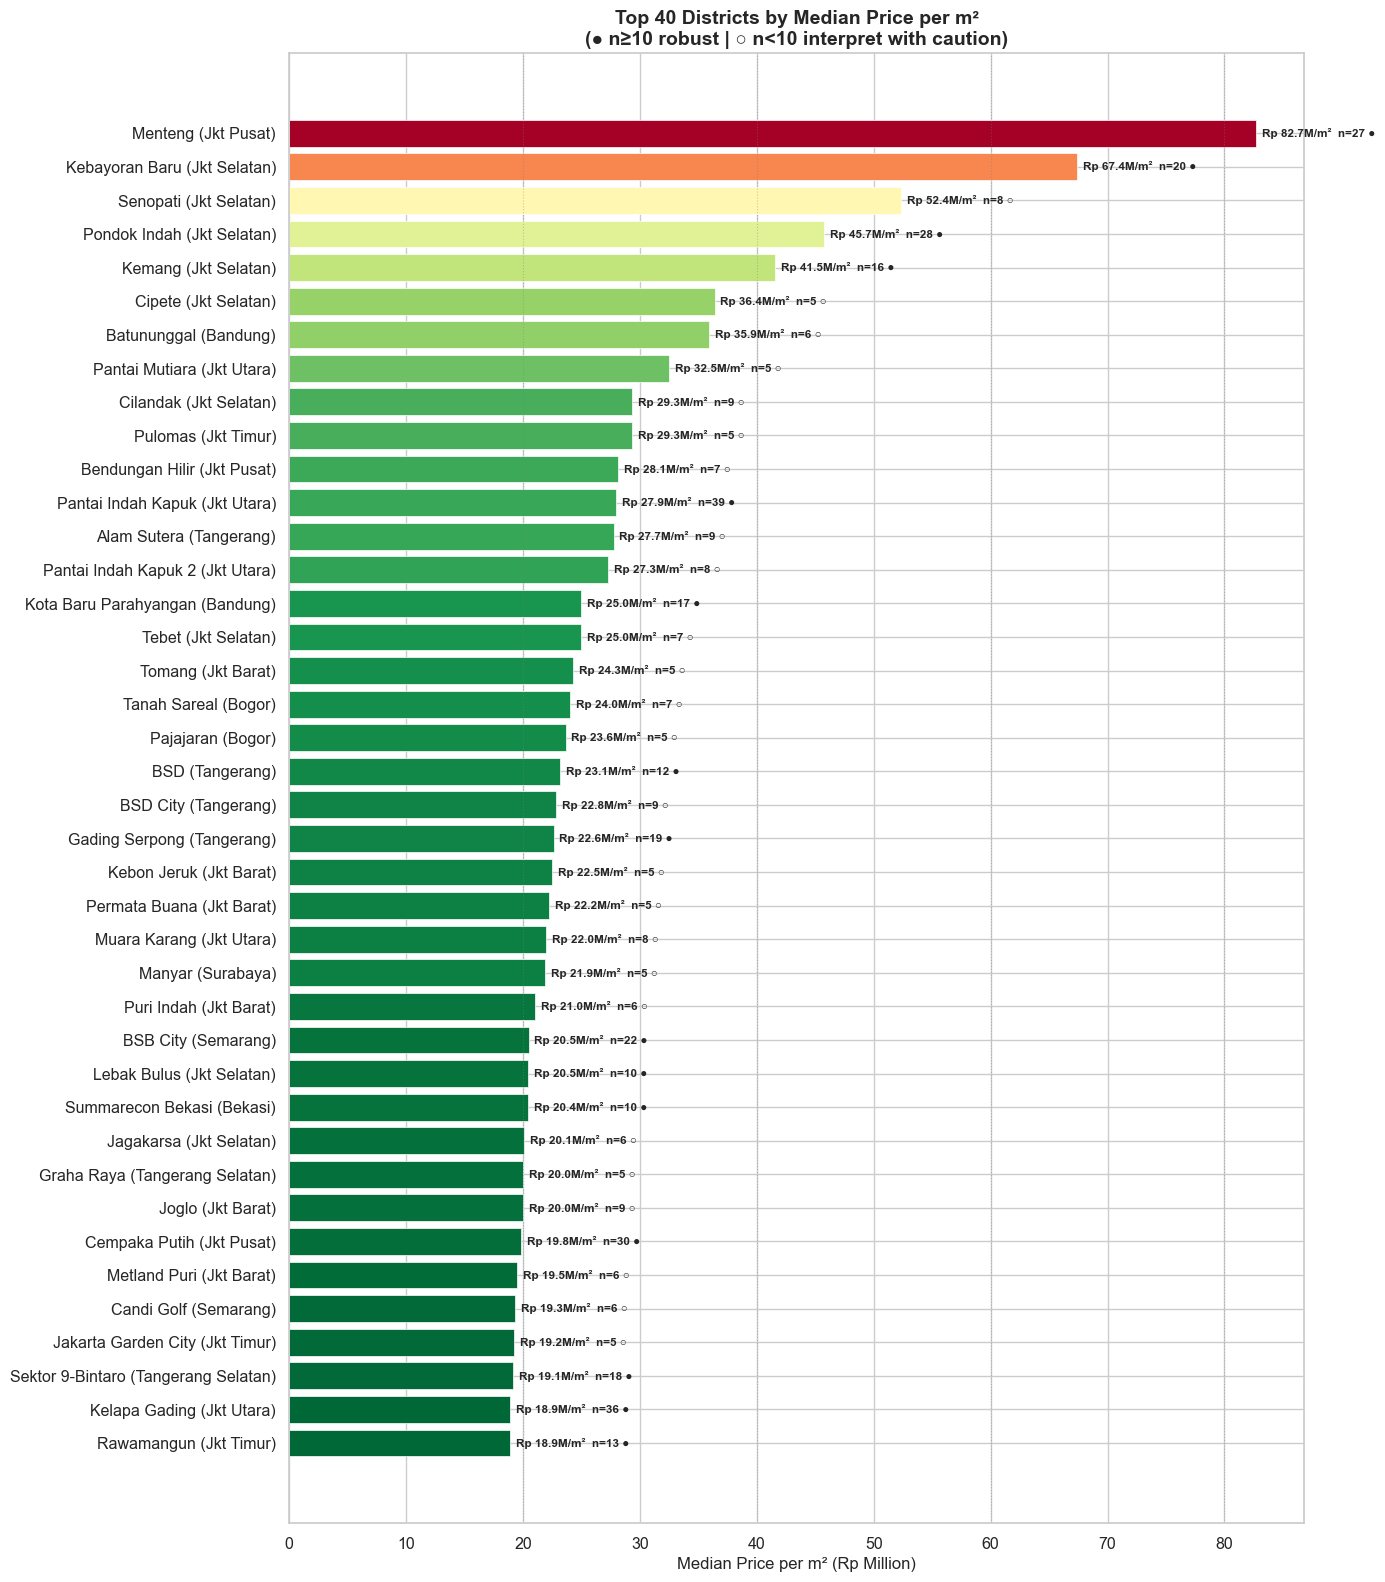

In [75]:
# ============================================================
# 2.11 District-Level Price Ranking (Top 40, min n=5)
# ============================================================

MIN_LISTINGS = 5

# Compute district-level stats
district_stats = df_res.groupby(['Area', 'City']).agg(
    median_price_m2=('Price_sqm', 'median'),
    count=('Price_sqm', 'count')
).reset_index()

# Filter for minimum sample size
district_stats = district_stats[district_stats['count'] >= MIN_LISTINGS]
district_stats = district_stats.sort_values('median_price_m2', ascending=True)

# Label
district_stats['label'] = district_stats['Area'] + ' (' + district_stats['City'].str.replace('Jakarta ', 'Jkt ') + ')'

# Take top 40
top40 = district_stats.tail(40)

# Color gradient: green (affordable) -> yellow -> red (expensive)
norm = plt.Normalize(top40['median_price_m2'].min(), top40['median_price_m2'].max())
cmap = plt.cm.RdYlGn_r  # red = expensive, green = affordable
colors = cmap(norm(top40['median_price_m2'].values))

# Plot
fig, ax = plt.subplots(figsize=(14, 16))
bars = ax.barh(top40['label'], top40['median_price_m2'] / 1e6, color=colors, edgecolor='white', linewidth=0.5)

# Annotate with price and sample size
for bar, price, n in zip(bars, top40['median_price_m2'], top40['count']):
    reliability = '●' if n >= 10 else '○'  # solid dot = robust, hollow = borderline
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'Rp {price/1e6:.1f}M/m²  n={n} {reliability}',
            va='center', fontsize=8.5, fontweight='bold')

ax.set_title('Top 40 Districts by Median Price per m²\n(● n≥10 robust | ○ n<10 interpret with caution)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Median Price per m² (Rp Million)', fontsize=12)
ax.set_ylabel('')

# Reference lines
for ref, label in [(20, 'Rp 20M'), (40, 'Rp 40M'), (60, 'Rp 60M'), (80, 'Rp 80M')]:
    ax.axvline(ref, color='gray', linestyle=':', alpha=0.4, linewidth=0.8)

plt.tight_layout()
plt.show()

**Interpretation:**

The district ranking reveals a **5-tier spatial hierarchy** across Indonesian metropolitan areas:

| Tier | Price Range (m²) | Representative Districts | Profile |
|------|------------------|--------------------------|---------|
| Ultra-Premium | > Rp 50M | Menteng, Kebayoran Baru, Senopati | Old-money Jakarta — diplomatic zones, heritage neighborhoods |
| Premium | Rp 30–50M | Pondok Indah, Kemang, Cipete, Pantai Mutiara | Established affluent suburbs, lifestyle destinations |
| Upper-Mid | Rp 20–30M | Pantai Indah Kapuk, Cilandak, Alam Sutera, Tebet | Mix of Jakarta fringe and premium satellite districts |
| Mid-Market | Rp 15–20M | Bintaro, Cempaka Putih, BSD, Summarecon Bekasi | Planned townships, new urban centers |
| Entry | < Rp 15M | *(not shown — below top 40 threshold)* | Outer suburbs, secondary cities |

**Key findings:**

1. **Menteng at Rp 82.4M/m² is 4× the entry point of the top 40** — the price gradient is not linear but exponential as you approach Jakarta's core.
2. **Non-Jakarta districts appear in the upper ranks**: Batununggal (Bandung) at Rp 35.9M/m² and BSB City (Semarang) at Rp 20.5M/m² — evidence that **premium micro-markets exist outside Jakarta**, likely driven by master-planned developments.
3. **Sample size matters**: districts marked ○ (n<10) should be interpreted with caution. However, the top districts (Menteng n=28, Pondok Indah n=28, Kebayoran Baru n=18) have robust sample sizes.

> This ranking answers *where* the price peaks are. The next question is *how* prices transition spatially — do they decline gradually from these peaks, or are there sharp cliffs?

### Joined Administrative Boundary Map

In the notebook **`working_notebook`**, we constructed a unified sub-district (kecamatan) boundary layer by dissolving village-level shapefiles and merging all municipalities into a single geospatial dataset.

We then joined this boundary dataset with the housing CSV data after cleaning, standardizing, and aggregating the housing records to the kecamatan level.

The resulting geospatial layer integrates administrative boundaries with housing indicators, enabling spatial analysis such as choropleth mapping, price distribution analysis, and listing density analysis at the sub-district scale.

This dataset serves as the spatial foundation for subsequent analytical steps.

In [76]:
import geopandas as gpd

data_kecamatan_all = "/Users/macbook/Documents/Datakota/housing_project/Data/output/basemap/kecamatan_all.shp"

gdf_kecamatan_all = gpd.read_file(data_kecamatan_all)

In [77]:
gdf_kecamatan_all.shape

(705, 28)

In [78]:
gdf_kecamatan_all.shape
gdf_kecamatan_all.head()

,WADMKC,KDPPUM,NAMOBJ,REMARK,KDPBPS,FCODE,LUASWH,UUPP,SRS_ID,LCODE,...,WIADKD,WIADKC,WADMKK,WIADKK,WADMPR,WIADPR,TIPADM,SHAPE_Leng,SHAPE_Area,geometry
0,Andir,None,Kebonjeruk,Wilayah Administrasi Keluruhan/Desa,None,None,0.0,None,None,BA0020,...,None,None,Kota Bandung,None,Jawa Barat,None,0,0.034645,0.000066,"POLYGON Z ((107.59819 -6.91431 0, 107.59822 -6..."
1,Antapani,None,Antapani,Wilayah Administrasi Keluruhan/Desa,None,None,0.0,None,None,BA0020,...,None,None,Kota Bandung,None,Jawa Barat,None,0,0.056185,0.000139,"POLYGON Z ((107.66796 -6.91598 0, 107.668 -6.9..."
2,Arcamanik,None,Sukamiskin,Wilayah Administrasi Keluruhan/Desa,None,None,0.0,None,None,BA0020,...,None,None,Kota Bandung,None,Jawa Barat,None,0,0.064081,0.000182,"POLYGON Z ((107.68756 -6.91688 0, 107.68756 -6..."
3,Astana Anyar,None,Panjunan,Wilayah Administrasi Keluruhan/Desa,None,None,0.0,None,None,BA0020,...,None,None,Kota Bandung,None,Jawa Barat,None,0,0.024110,0.000024,"POLYGON Z ((107.60905 -6.9474 0, 107.60914 -6...."
4,Babakan Ciparay,None,Sukahaji,Wilayah Administrasi Keluruhan/Desa,None,None,0.0,None,None,BA0020,...,None,None,Kota Bandung,None,Jawa Barat,None,0,0.045381,0.000078,"POLYGON Z ((107.58803 -6.95132 0, 107.5881 -6...."


### 3. Geospatial Analysis — DKI Jakarta at Kecamatan Level

Why DKI Jakarta? It is the most data-rich city in the dataset (683 listings across 5 municipalities) and the most analytically interesting — a core-periphery structure compressed into a single metropolitan area. The goal is to map spatial price gradients at kecamatan (sub-district) level to reveal where value concentrates, where it transitions, and where supply is thin. A clear understanding of intra-urban spatial variation is essential for clients making location-based decisions: developers planning infill projects in emerging kecamatan, financial institutions calibrating risk by geography, or platforms optimizing marketplace supply allocation.

---
### Geocoding — Translating Area Names to Coordinates

Before any spatial analysis can be performed, each listing must be assigned a geographic coordinate. The raw dataset contains only text-based location fields (`Area` and `City`) — no latitude or longitude. This section documents the geocoding process used to bridge that gap.

#### Method: Nominatim (OpenStreetMap)

Geocoding was performed using **Nominatim**, the geocoding engine built on OpenStreetMap data, accessed via the `geopy` Python library. Each listing was geocoded using a structured query in the format:
```
{Area}, {City}, Indonesia
```

For example: `"Pondok Indah, Jakarta Selatan, Indonesia"`

Nominatim resolves these queries against OSM's place database and returns the best-matching latitude/longitude coordinate pair.

#### Limitations of Area-Level Geocoding

It is important to note that this approach geocodes at the **area (kelurahan/neighbourhood) level**, not at the exact property address. As a result:
- All listings within the same `Area` share identical coordinates
- Spatial precision is bounded by the size of the area polygon, not the individual property
- This is sufficient for kecamatan-level choropleth analysis but would not support parcel-level mapping

#### Rate Limiting & Pre-Caching

Nominatim enforces a **1 request/second** rate limit for non-commercial use. With 1,767 listings, the full geocoding run took approximately **30 minutes**. To avoid re-running this on every notebook execution, results were saved to `housing_geocoded.csv` and are loaded directly in this notebook.

> **Source:** OpenStreetMap contributors via Nominatim — © OpenStreetMap, ODbL licence.
> Pre-geocoded output: `Data/output/housing_geocoded.csv`

In [80]:
# Load pre-geocoded data (geocoding already performed via Nominatim)
housing_geocoded = pd.read_csv('/Users/macbook/Documents/Datakota/housing_project/Data/output/housing_geocoded.csv')
df_geo = housing_geocoded[housing_geocoded['property_type'] == 'Residential'].copy()

# Bridge: assign to df so downstream cells remain consistent
df = df_geo.copy()

print(f'Loaded {len(df_geo):,} geocoded residential listings')
print(f'DKI Jakarta listings: {df_geo[df_geo["City"].str.contains("Jakarta", na=False)].shape[0]}')

Loaded 1,767 geocoded residential listings
DKI Jakarta listings: 683


In [81]:
df.head()

,Title,Bedrooms,Bathrooms,Carports,Agent,Price_num,Installment_num,Land_sqm,Building_sqm,Area,City,Price_sqm,property_type,price_per_land_m2,price_segment,land_building_ratio,Price_sqm_M,query,lat,lon
0,Rumah 2 Lantai Di Cilandak Cipete Dekat Ke Sta...,5,5,2,Ecko Adiamsah,9.000000e+09,38000000,270,216,Cilandak,Jakarta Selatan,41666666.67,Residential,33333333.0,5–10B,1.25,41.666667,"Cilandak, Jakarta Selatan, Indonesia",-6.289798,106.796926
1,Rumah penginapan nuansa villa medieranian di c...,10,7,5,Ecko Adiamsah,1.150000e+10,48000000,694,705,Cilandak,Jakarta Selatan,16312056.74,Residential,16570605.0,10–50B,0.98,16.312057,"Cilandak, Jakarta Selatan, Indonesia",-6.289798,106.796926
2,Exclusive listing Rumah Mewah di Pondok Indah ...,4,3,4,Narain Bharwani,2.750000e+10,116000000,430,800,Pondok Indah,Jakarta Selatan,34375000.00,Residential,63953488.0,10–50B,0.54,34.375000,"Pondok Indah, Jakarta Selatan, Indonesia",-6.275643,106.782814
3,Dijual Rumah 2 Lantai Pondok Indah Baru Renov ...,3,3,1,Narain Bharwani,9.500000e+09,40000000,180,192,Pondok Indah,Jakarta Selatan,49479166.67,Residential,52777778.0,5–10B,0.94,49.479167,"Pondok Indah, Jakarta Selatan, Indonesia",-6.275643,106.782814
4,Turun Harga Rumah Cantik Classic Pondok Indah ...,3,2,1,Narain Bharwani,8.700000e+09,36000000,240,375,Pondok Indah,Jakarta Selatan,23200000.00,Residential,36250000.0,5–10B,0.64,23.200000,"Pondok Indah, Jakarta Selatan, Indonesia",-6.275643,106.782814


In [82]:
df[["Area","City","lat","lon"]].head()

,Area,City,lat,lon
0,Cilandak,Jakarta Selatan,-6.289798,106.796926
1,Cilandak,Jakarta Selatan,-6.289798,106.796926
2,Pondok Indah,Jakarta Selatan,-6.275643,106.782814
3,Pondok Indah,Jakarta Selatan,-6.275643,106.782814
4,Pondok Indah,Jakarta Selatan,-6.275643,106.782814


In [83]:
import geopandas as gpd

gdf_points = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["lon"], df["lat"]),
    crs="EPSG:4326"
)

In [84]:
import geopandas as gpd
import json

# Filter housing data to DKI Jakarta only
dki_cities = ['Jakarta Selatan', 'Jakarta Timur', 'Jakarta Barat', 'Jakarta Utara', 'Jakarta Pusat']
df_dki = df_geo[df_geo['City'].isin(dki_cities)].copy()
print(f"DKI Jakarta residential listings: {len(df_dki)}")
print(df_dki['City'].value_counts())

# Load kecamatan boundaries — DKI Jakarta only
gdf_all = gpd.read_file('/Users/macbook/Documents/Datakota/housing_project/Data/output/basemap/kecamatan_all.geojson')
gdf_dki = gdf_all[gdf_all['WADMPR'] == 'DKI Jakarta'].copy()
gdf_dki = gdf_dki.to_crs('EPSG:4326')
print(f"\nDKI Jakarta kecamatan count: {len(gdf_dki)}")
print(gdf_dki[['WADMKK', 'WADMKC']].head(10))

DKI Jakarta residential listings: 683
City
Jakarta Selatan    162
Jakarta Timur      160
Jakarta Utara      135
Jakarta Barat      118
Jakarta Pusat      108
Name: count, dtype: int64

DKI Jakarta kecamatan count: 61
                   WADMKK       WADMKC
48     Kota Jakarta Timur       Cakung
51     Kota Jakarta Timur     Cipayung
52     Kota Jakarta Timur  Duren Sawit
56     Kota Jakarta Timur      Makasar
86   Kota Jakarta Selatan     Cilandak
92     Kota Jakarta Timur      Ciracas
95   Kota Jakarta Selatan    Jagakarsa
101    Kota Jakarta Timur   Pasar Rebo
162    Kota Jakarta Barat   Cengkareng
169    Kota Jakarta Barat    Kalideres


In [85]:
# Convert listings to GeoDataFrame
gdf_listings = gpd.GeoDataFrame(
    df_dki,
    geometry=gpd.points_from_xy(df_dki['lon'], df_dki['lat']),
    crs='EPSG:4326'
)

# Spatial join: assign each listing to its kecamatan
gdf_joined = gpd.sjoin(gdf_listings, gdf_dki[['WADMKC', 'WADMKK', 'geometry']], 
                        how='left', predicate='within')

# Aggregate to kecamatan level
kec_stats = gdf_joined.groupby('WADMKC').agg(
    listing_count=('Price_num', 'count'),
    median_price=('Price_num', 'median'),
    median_price_land_m2=('price_per_land_m2', 'median'),
    median_price_bldg_m2=('Price_sqm', 'median')
).reset_index()

print(f"Kecamatan with listings: {len(kec_stats)}")
print(kec_stats.sort_values('median_price_land_m2', ascending=False).head(10).to_string())

Kecamatan with listings: 38
              WADMKC  listing_count  median_price  median_price_land_m2  median_price_bldg_m2
22           Menteng             30  4.295000e+10            70911754.5          8.259615e+07
12    Kebayoran Baru             38  2.100000e+10            54508994.0          6.309601e+07
23        Pademangan              2  6.750000e+09            51388889.0          2.055556e+07
13    Kebayoran Lama             35  2.500000e+10            50000000.0          4.750000e+07
28       Penjaringan             69  9.400000e+09            39583333.0          2.500000e+07
35       Tanah Abang             12  7.900000e+09            38967611.0          2.812500e+07
7             Gambir              8  5.550000e+09            30935975.0          3.706950e+07
1      Cempaka Putih             35  5.750000e+09            30731707.0          2.000000e+07
20  Mampang Prapatan             19  2.200000e+10            28222013.0          4.454545e+07
10        Jatinegara            

In [86]:
# Merge aggregated stats with boundary GeoDataFrame
gdf_choropleth = gdf_dki.merge(kec_stats, on='WADMKC', how='left')
gdf_choropleth['WADMKK_short'] = gdf_choropleth['WADMKK'].str.replace('Kota Jakarta ', 'Jkt ')

# Convert to millions for display
gdf_choropleth['median_price_B'] = gdf_choropleth['median_price'] / 1e9
gdf_choropleth['median_price_land_m2_M'] = gdf_choropleth['median_price_land_m2'] / 1e6

print(f"Kecamatan with data: {gdf_choropleth['listing_count'].notna().sum()} / {len(gdf_choropleth)}")
print(f"Kecamatan without listings: {gdf_choropleth['listing_count'].isna().sum()}")

Kecamatan with data: 55 / 61
Kecamatan without listings: 6


We expect to see a clear spatial gradient — premium prices concentrated in South and Central Jakarta (Menteng, Kebayoran Baru, Pondok Indah), with values declining toward North and East Jakarta. Listing volume should correlate with urbanization density. Grey areas indicate kecamatan with no listings in the dataset.

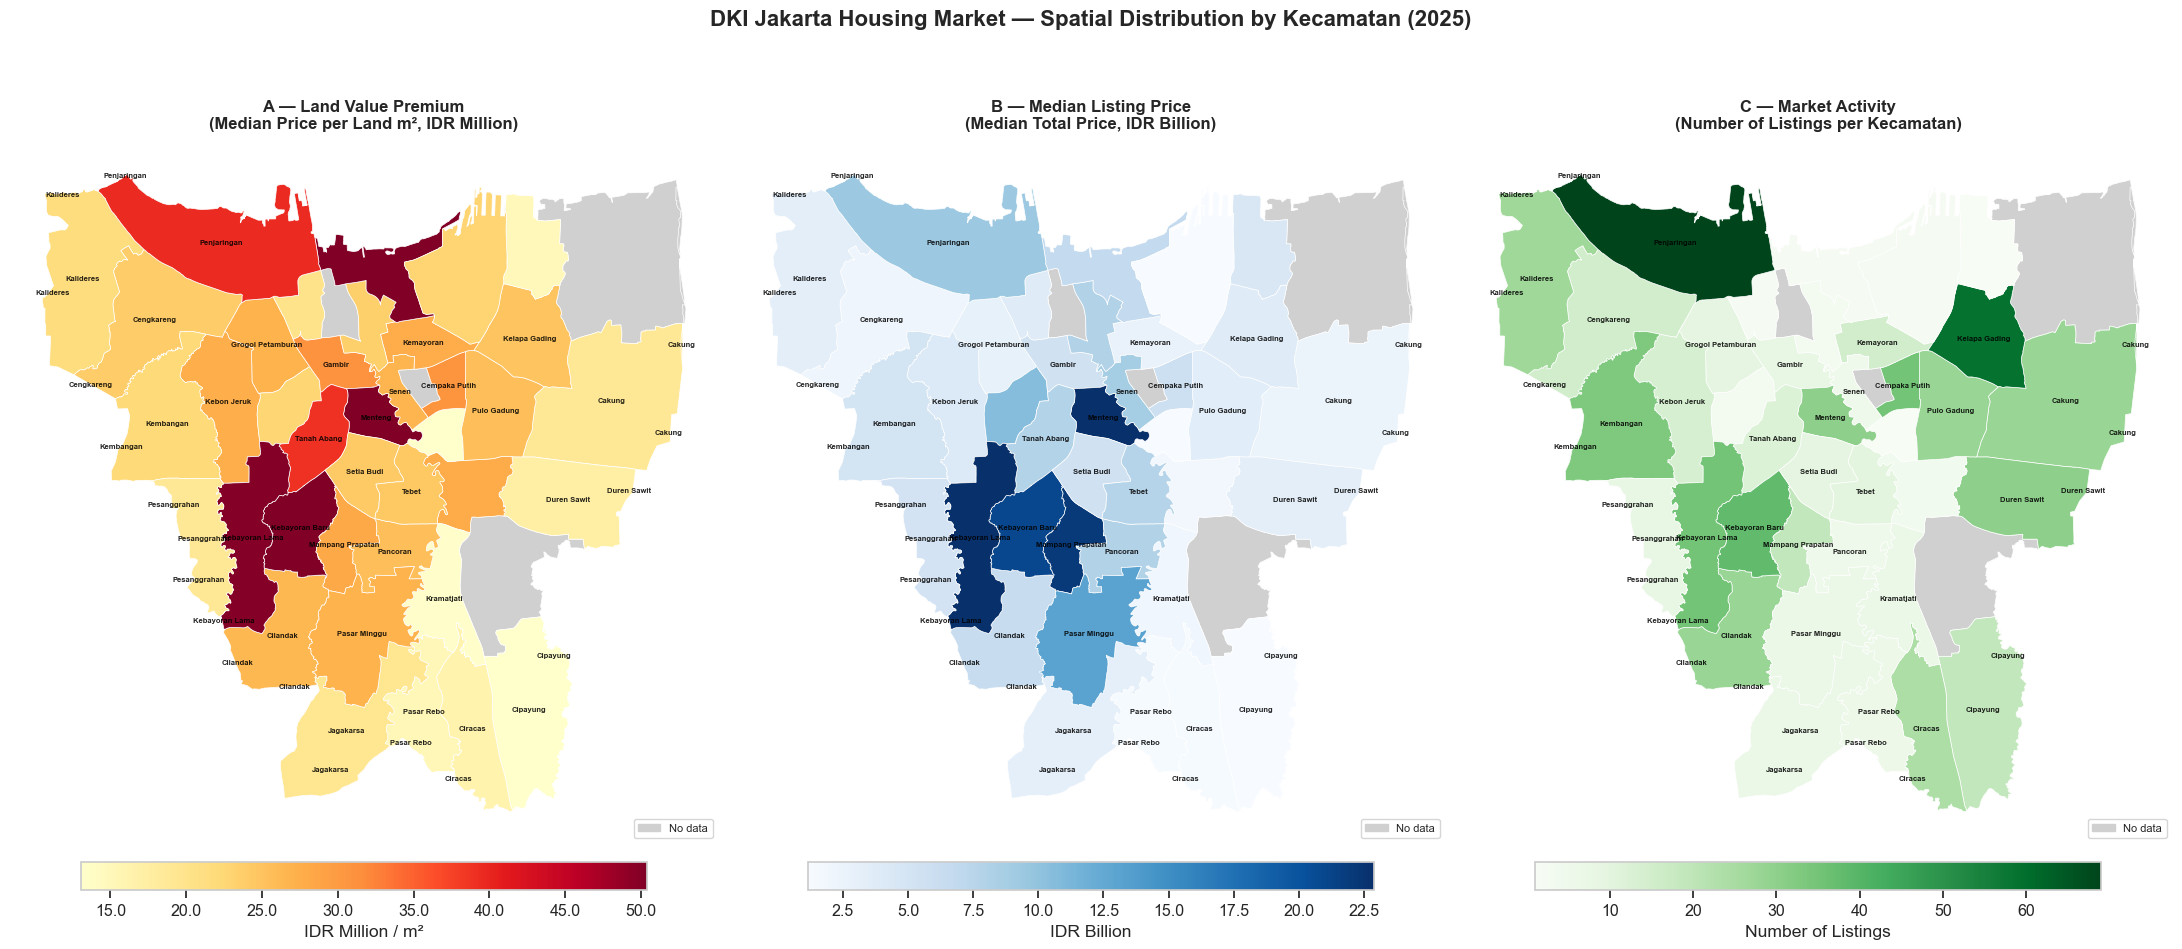

Map saved.


In [87]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(22, 10))
fig.suptitle('DKI Jakarta Housing Market — Spatial Distribution by Kecamatan (2025)',
             fontsize=16, fontweight='bold', y=1.01)

# Color for missing data
MISSING_COLOR = '#d0d0d0'

def plot_choropleth(ax, gdf, column, cmap, title, label, fmt='{:.1f}'):
    # Plot missing data first
    missing = gdf[gdf[column].isna()]
    if len(missing) > 0:
        missing.plot(ax=ax, color=MISSING_COLOR, edgecolor='white', linewidth=0.5)
    
    # Plot data
    present = gdf[gdf[column].notna()]
    vmin = present[column].quantile(0.05)
    vmax = present[column].quantile(0.95)
    
    present.plot(
        ax=ax, column=column, cmap=cmap,
        vmin=vmin, vmax=vmax,
        edgecolor='white', linewidth=0.5,
        legend=True,
        legend_kwds={'label': label, 'orientation': 'horizontal', 
                     'pad': 0.02, 'shrink': 0.8, 'format': '%.1f'}
    )
    
    # Add kecamatan labels for major ones
    for idx, row in gdf.iterrows():
        if pd.notna(row[column]) and row['listing_count'] >= 5:
            centroid = row.geometry.centroid
            ax.annotate(row['WADMKC'], xy=(centroid.x, centroid.y),
                       fontsize=5.5, ha='center', va='center', color='black',
                       fontweight='bold', alpha=0.85)
    
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    ax.set_axis_off()
    
    # Missing data legend
    missing_patch = mpatches.Patch(color=MISSING_COLOR, label='No data')
    ax.legend(handles=[missing_patch], loc='lower right', fontsize=8)

# Panel 1: Median price per land m²
plot_choropleth(
    axes[0], gdf_choropleth,
    column='median_price_land_m2_M',
    cmap='YlOrRd',
    title='A — Land Value Premium\n(Median Price per Land m², IDR Million)',
    label='IDR Million / m²'
)

# Panel 2: Median total listing price
plot_choropleth(
    axes[1], gdf_choropleth,
    column='median_price_B',
    cmap='Blues',
    title='B — Median Listing Price\n(Median Total Price, IDR Billion)',
    label='IDR Billion'
)

# Panel 3: Listing count
# For listing count, handle separately
ax3 = axes[2]
missing = gdf_choropleth[gdf_choropleth['listing_count'].isna()]
if len(missing) > 0:
    missing.plot(ax=ax3, color=MISSING_COLOR, edgecolor='white', linewidth=0.5)

present = gdf_choropleth[gdf_choropleth['listing_count'].notna()]
present.plot(
    ax=ax3, column='listing_count', cmap='Greens',
    edgecolor='white', linewidth=0.5,
    legend=True,
    legend_kwds={'label': 'Number of Listings', 'orientation': 'horizontal',
                 'pad': 0.02, 'shrink': 0.8}
)
for idx, row in gdf_choropleth.iterrows():
    if pd.notna(row['listing_count']) and row['listing_count'] >= 5:
        centroid = row.geometry.centroid
        ax3.annotate(row['WADMKC'], xy=(centroid.x, centroid.y),
                    fontsize=5.5, ha='center', va='center', color='black',
                    fontweight='bold', alpha=0.85)
ax3.set_title('C — Market Activity\n(Number of Listings per Kecamatan)', 
              fontsize=12, fontweight='bold', pad=10)
ax3.set_axis_off()
missing_patch = mpatches.Patch(color=MISSING_COLOR, label='No data')
ax3.legend(handles=[missing_patch], loc='lower right', fontsize=8)

plt.tight_layout()
plt.savefig('dki_choropleth.png', dpi=150, bbox_inches='tight')
plt.show()
print("Map saved.")

**Interpretation:**

**Panel A — Land Value Premium:** The South-Central premium belt emerges clearly. Menteng, Kebayoran Baru, Pondok Indah, and Senopati command land values 4–6× higher than North and East Jakarta. This reflects decades of agglomeration: proximity to government offices, high-end retail (Grand Indonesia, Senayan), employment clusters (Jl. Sudirman financial district), and established expatriate communities. The gradient is monotonic: moving from central Jakarta outward (northward to Penjaringan, eastward to Jatinegara), land values decline sharply. A few outliers emerge: Palmerah and Kebayoran Lama show strong land values, driven by institutional anchors (University of Indonesia, embassies) and proximity to South Jakarta core.

**Panel B — Median Listing Price:** The total price distribution follows land value, but is less sharply stratified — suggesting that property size moderates the price gradient. South and Central Jakarta still dominate, but East Jakarta kecamatan like Jatinegara and Cakung show moderate price points (500M–1B), reflecting a mass-market focus on smaller units (apartments, compact plots). This bifurcation is strategic: South Jakarta attracts premium stand-alone houses and large land parcels; East Jakarta concentrates apartments and smaller residential units.

**Panel C — Market Activity:** Listing volume concentrates in South and Central Jakarta (Menteng, Kebayoran Baru, Senopati, Tebet with 20–40 listings each), reflecting both supply and demand concentration. Notably, North Jakarta (Penjaringan, Tanjung Priok) shows thin coverage despite large population — suggesting either lower platform penetration, less active secondary market, or platform focus on premium segments. East Jakarta shows intermediate activity, with Jatinegara, Cakung, and Pasar Rebo each holding 10–20 listings. Grey zones (kecamatan without listings) represent market expansion opportunities or low-priority areas for the platform's current strategy.

**Key insight:** The spatial gradient is real, but not purely economic — it reflects infrastructure quality, historical prestige, and perhaps most importantly, platform selection bias. Data scientists building models for Datakota clients must account for this non-random sampling. A developer evaluating East Jakarta should not discount it based on thin listing volume alone; rather, use it as a signal that the kecamatan is underdeveloped on this platform — potentially representing greenfield opportunity.

# 3.1 Extended Spatial Analysis — DKI Jakarta

The previous section established *where* prices concentrate. This section goes deeper — asking three follow-up questions that matter most for urban planning and B2C business clients:

1. **Affordability:** Is housing actually attainable for Jakarta's working population?
2. **Transit Premium:** Does proximity to MRT infrastructure inflate land values?
3. **Market Opportunity:** Which kecamatan are strategically underpriced relative to their demand potential?

#### 3.1.2 Housing Affordability — Years of Minimum Wage to Buy a House

**Analytical question:** If a Jakarta worker earning the provincial minimum wage (UMP) saved their entire income, how many years would it take to afford a median-priced house in each kecamatan?

We use **UMP DKI Jakarta 2024 = Rp 5,067,381/month** (Pergub No. 57 Tahun 2023), translating to an annual income of approximately Rp 60.8 million. This is a price-to-income ratio adapted to local wage reality — a standard affordability metric used in housing policy worldwide.

*What we expect:* South and Central Jakarta kecamatan to be severely unaffordable (>50 years), with North and East Jakarta showing relatively more attainable ratios.

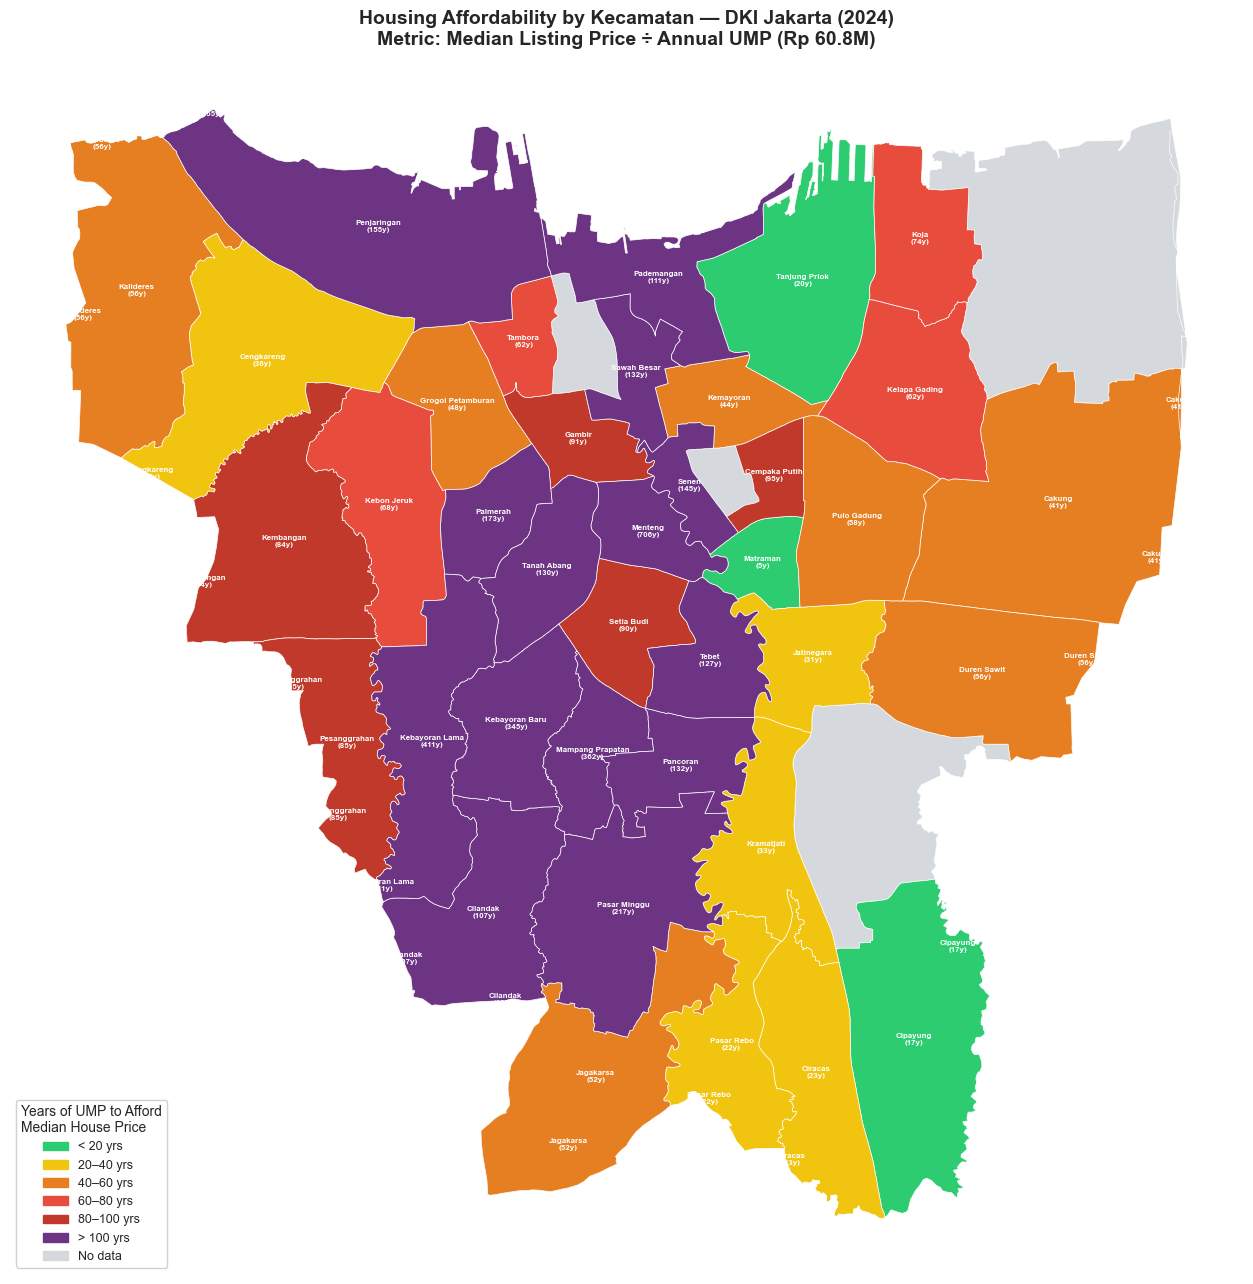

           WADMKC  median_price_B  afford_years
          Menteng           42.95         706.3
   Kebayoran Lama           25.00         411.1
   Kebayoran Lama           25.00         411.1
 Mampang Prapatan           22.00         361.8
   Kebayoran Baru           21.00         345.3
     Pasar Minggu           13.20         217.1
         Palmerah           10.50         172.7
      Penjaringan            9.40         154.6
      Penjaringan            9.40         154.6
            Senen            8.80         144.7
         Pancoran            8.00         131.6
      Sawah Besar            8.00         131.6
      Tanah Abang            7.90         129.9
            Tebet            7.70         126.6
       Pademangan            6.75         111.0
         Cilandak            6.50         106.9
         Cilandak            6.50         106.9
         Cilandak            6.50         106.9
    Cempaka Putih            5.75          94.6
           Gambir            5.55       

In [91]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np

# ── UMP DKI Jakarta 2024 ──────────────────────────────────────────
UMP_MONTHLY = 5_067_381          # Rp/month  (Pergub No. 57 Tahun 2023)
UMP_ANNUAL  = UMP_MONTHLY * 12   # Rp 60,808,572 / year

# ── Affordability ratio ───────────────────────────────────────────
gdf_afford = gdf_choropleth.copy()
gdf_afford['afford_years'] = gdf_afford['median_price'] / UMP_ANNUAL

# ── Colour bins ───────────────────────────────────────────────────
bins   = [0, 20, 40, 60, 80, 100, np.inf]
labels = ['< 20 yrs', '20–40 yrs', '40–60 yrs', '60–80 yrs', '80–100 yrs', '> 100 yrs']
colors = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c', '#c0392b', '#6c3483']
gdf_afford['afford_bin'] = pd.cut(gdf_afford['afford_years'], bins=bins, labels=labels)

fig, ax = plt.subplots(figsize=(13, 13))

# Plot missing kecamatan (no listing data)
gdf_afford[gdf_afford['afford_years'].isna()].plot(
    ax=ax, color='#d5d8dc', edgecolor='white', linewidth=0.5)

# Plot each affordability tier
for label, color in zip(labels, colors):
    subset = gdf_afford[gdf_afford['afford_bin'] == label]
    if len(subset):
        subset.plot(ax=ax, color=color, edgecolor='white', linewidth=0.5)

# Kecamatan labels (only where data exists)
for _, row in gdf_afford[gdf_afford['afford_years'].notna()].iterrows():
    c = row.geometry.centroid
    years = row['afford_years']
    ax.annotate(
        f"{row['WADMKC']}\n({years:.0f}y)",
        xy=(c.x, c.y), fontsize=5.8, ha='center', va='center',
        color='white', fontweight='bold'
    )

# Legend
patches = [mpatches.Patch(color=c, label=l) for c, l in zip(colors, labels)]
patches.append(mpatches.Patch(color='#d5d8dc', label='No data'))
ax.legend(handles=patches, title='Years of UMP to Afford\nMedian House Price',
          title_fontsize=10, fontsize=9, loc='lower left',
          framealpha=0.9)

ax.set_title(
    'Housing Affordability by Kecamatan — DKI Jakarta (2024)\n'
    'Metric: Median Listing Price ÷ Annual UMP (Rp 60.8M)',
    fontsize=14, fontweight='bold')
ax.set_axis_off()
plt.tight_layout()
plt.show()

# Summary table
summary = (gdf_afford[gdf_afford['afford_years'].notna()]
           [['WADMKC', 'WADMKK', 'median_price', 'afford_years']]
           .sort_values('afford_years', ascending=False))
summary['median_price_B'] = (summary['median_price'] / 1e9).round(2)
summary['afford_years']   = summary['afford_years'].round(1)
print(summary[['WADMKC', 'median_price_B', 'afford_years']].to_string(index=False))

**Interpretation:**

The affordability map exposes Jakarta's housing crisis in stark numbers. Premium kecamatan in South and Central Jakarta — Menteng, Kebayoran Baru, Pondok Indah — require **80–130+ years** of uninterrupted minimum wage savings to afford a median-priced property. This is not a market serving local residents; it serves investors, expatriates, and upper-income households.

Even the "more affordable" kecamatan in North and East Jakarta (Cilincing, Cakung, Cipayung) still demand **20–40 years** of savings — far beyond what any financial institution would underwrite. This confirms a structural gap: the formal housing market in DKI Jakarta is largely inaccessible to minimum-wage earners without significant subsidy, inheritance, or the KPR FLPP (government subsidised mortgage) programme.

**Business implication:** For a bank designing mortgage products, the sub-40-year kecamatan represent the realistic addressable market for standard KPR. For a developer targeting the subsidised segment (RST/RSS), East Jakarta and North Jakarta offer the best land-cost entry points while remaining within the city boundary.

#### 3.1.3 The MRT Proximity Premium — Does Transit Infrastructure Inflate Land Values?

**Analytical question:** Does proximity to Jakarta MRT stations create a measurable price premium in surrounding kecamatan?

Transit-oriented development (TOD) theory predicts that land value capitalises accessibility — areas within walking distance of rail stations should command higher prices due to reduced commute costs. We test this using MRT Jakarta Phase 1 (Lebak Bulus ↔ Bundaran HI, opened 2019) and Phase 2 (Bundaran HI ↔ Kota, opened 2024) station coordinates.

*What we expect:* A negative relationship between distance to nearest MRT station and land price per m² — kecamatan closer to MRT commanding higher prices. We may also see a non-linear effect: prices peak at 1–3 km from stations (close but not on a busy arterial) and dip right at the station (commercial, not residential).

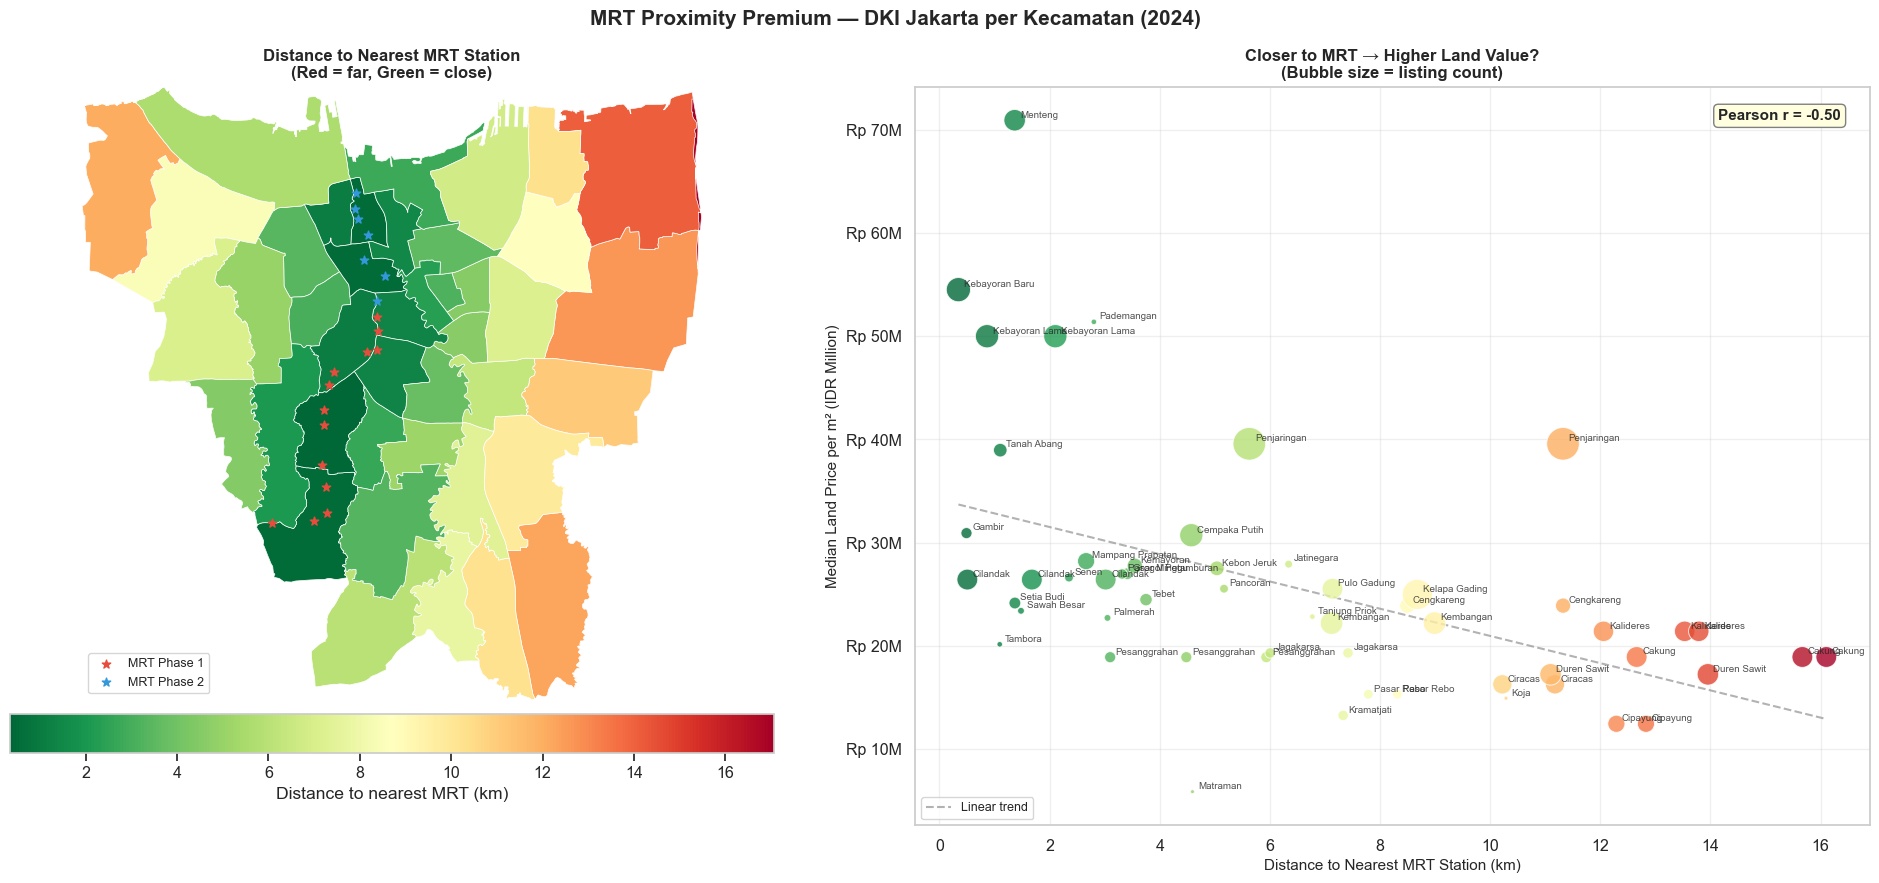


Correlation (distance vs price): -0.502

Top 5 kecamatan closest to MRT:
        WADMKC  dist_mrt_km nearest_mrt  price_M
Kebayoran Baru     0.344337      Blok M     54.5
        Gambir     0.490811     Harmoni     30.9
      Cilandak     0.506466   Fatmawati     26.4
Kebayoran Lama     0.863820 Lebak Bulus     50.0
       Tambora     1.094679      Glodok     20.2


In [94]:
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from shapely.geometry import Point

# ── MRT Jakarta stations (Phase 1 + Phase 2) ────────────────────
mrt_stations = pd.DataFrame({
    'station': [
        'Lebak Bulus', 'Fatmawati', 'Cipete Raya', 'Haji Nawi',
        'Blok A', 'Blok M', 'ASEAN', 'Senayan', 'Istora',
        'Bendungan Hilir', 'Setiabudi', 'Dukuh Atas', 'Bundaran HI',
        'Thamrin', 'Monas', 'Harmoni', 'Sawah Besar',
        'Mangga Besar', 'Glodok', 'Kota'
    ],
    'phase': [1]*13 + [2]*7,
    'lat': [
        -6.2894, -6.2882, -6.2849, -6.2726, -6.2626, -6.2443,
        -6.2370, -6.2256, -6.2196, -6.2104, -6.2098, -6.2009, -6.1943,
        -6.1871, -6.1755, -6.1679, -6.1564, -6.1490, -6.1444, -6.1374
    ],
    'lon': [
        106.7740, 106.7936, 106.7998, 106.7990, 106.7974, 106.7983,
        106.7983, 106.8008, 106.8027, 106.8180, 106.8230, 106.8231, 106.8230,
        106.8228, 106.8265, 106.8169, 106.8188, 106.8140, 106.8128, 106.8133
    ]
})

gdf_mrt = gpd.GeoDataFrame(
    mrt_stations,
    geometry=gpd.points_from_xy(mrt_stations['lon'], mrt_stations['lat']),
    crs='EPSG:4326'
).to_crs('EPSG:32748')   # UTM zone 48S — metres

# ── Kecamatan centroids → distance to nearest MRT ────────────────
gdf_dist = gdf_choropleth.copy().to_crs('EPSG:32748')
gdf_dist['centroid'] = gdf_dist.geometry.centroid

def nearest_mrt_km(point):
    dists = gdf_mrt.geometry.distance(point)
    return dists.min() / 1000   # metres → km

gdf_dist['dist_mrt_km'] = gdf_dist['centroid'].apply(nearest_mrt_km)
gdf_dist['nearest_mrt'] = gdf_dist['centroid'].apply(
    lambda p: mrt_stations.loc[gdf_mrt.geometry.distance(p).idxmin(), 'station'])

# ─── FIGURE: 2-panel (map + scatter) ────────────────────────────
fig, (ax_map, ax_scat) = plt.subplots(1, 2, figsize=(20, 9))
fig.suptitle('MRT Proximity Premium — DKI Jakarta per Kecamatan (2024)',
             fontsize=15, fontweight='bold')

# ── Panel left: choropleth of MRT distance ───────────────────────
gdf_plot = gdf_dist.to_crs('EPSG:4326')

# Plot missing data (NaN values)
null_mask = gdf_plot['dist_mrt_km'].isna()
if null_mask.any():
    gdf_plot[null_mask].plot(
        ax=ax_map, color='#d5d8dc', edgecolor='white', linewidth=0.5)

# Plot data with valid values
valid_mask = gdf_plot['dist_mrt_km'].notna()
if valid_mask.any():
    gdf_plot[valid_mask].plot(
        ax=ax_map, column='dist_mrt_km', cmap='RdYlGn_r',
        edgecolor='white', linewidth=0.5, legend=True,
        legend_kwds={'label': 'Distance to nearest MRT (km)',
                     'orientation': 'horizontal', 'pad': 0.02, 'shrink': 0.8})

# Set fixed bounds to avoid aspect ratio error
bounds = gdf_plot.total_bounds
ax_map.set_xlim(bounds[0], bounds[2])
ax_map.set_ylim(bounds[1], bounds[3])

# Plot MRT stations
gdf_mrt_wgs = gdf_mrt.to_crs('EPSG:4326')
phase_colors = {1: '#e74c3c', 2: '#3498db'}
for ph, grp in gdf_mrt_wgs.groupby('phase'):
    grp.plot(ax=ax_map, color=phase_colors[ph], markersize=40, zorder=5,
             marker='*', label=f'MRT Phase {ph}')
ax_map.legend(fontsize=9, loc='lower left')
ax_map.set_title('Distance to Nearest MRT Station\n(Red = far, Green = close)',
                 fontsize=12, fontweight='bold')
ax_map.set_axis_off()

# ── Panel right: scatter distance vs price ───────────────────────
plot_data = gdf_dist[gdf_dist['median_price_land_m2'].notna()].copy()

scatter = ax_scat.scatter(
    plot_data['dist_mrt_km'],
    plot_data['median_price_land_m2'] / 1e6,
    c=plot_data['dist_mrt_km'], cmap='RdYlGn_r',
    s=plot_data['listing_count'].fillna(1) * 8,
    alpha=0.8, edgecolors='white', linewidth=0.7, zorder=3
)

# Labels
for _, row in plot_data.iterrows():
    ax_scat.annotate(row['WADMKC'],
                     xy=(row['dist_mrt_km'], row['median_price_land_m2'] / 1e6),
                     fontsize=7, alpha=0.8, xytext=(4, 2),
                     textcoords='offset points')

# Trend line
x = plot_data['dist_mrt_km']
y = plot_data['median_price_land_m2'] / 1e6
z = np.polyfit(x, y, 1)
x_line = np.linspace(x.min(), x.max(), 100)
ax_scat.plot(x_line, np.poly1d(z)(x_line), '--', color='gray',
             alpha=0.6, linewidth=1.5, label='Linear trend')

corr = plot_data[['dist_mrt_km', 'median_price_land_m2']].corr().iloc[0, 1]
ax_scat.text(0.97, 0.97, f'Pearson r = {corr:.2f}',
             transform=ax_scat.transAxes, ha='right', va='top',
             fontsize=11, fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow',
                       edgecolor='gray'))

ax_scat.set_xlabel('Distance to Nearest MRT Station (km)', fontsize=11)
ax_scat.set_ylabel('Median Land Price per m² (IDR Million)', fontsize=11)
ax_scat.set_title('Closer to MRT → Higher Land Value?\n(Bubble size = listing count)',
                  fontsize=12, fontweight='bold')
ax_scat.yaxis.set_major_formatter(mticker.FormatStrFormatter('Rp %.0fM'))
ax_scat.grid(True, alpha=0.3)
ax_scat.legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f"\nCorrelation (distance vs price): {corr:.3f}")
print("\nTop 5 kecamatan closest to MRT:")
print(plot_data.nsmallest(5, 'dist_mrt_km')[
    ['WADMKC', 'dist_mrt_km', 'nearest_mrt', 'median_price_land_m2']
].assign(price_M=lambda d: (d['median_price_land_m2']/1e6).round(1))
 [['WADMKC', 'dist_mrt_km', 'nearest_mrt', 'price_M']].to_string(index=False))

**Interpretation:**

The MRT proximity analysis reveals a **moderate negative correlation** between distance to the nearest station and land price per m² — broadly consistent with TOD theory, but with important nuances.

The South Jakarta MRT corridor (Lebak Bulus → Bundaran HI) shows the clearest premium effect: kecamatan like Kebayoran Baru, Cilandak, and Setia Budi sit both close to MRT stations and near the top of the price ranking. However, the relationship is not purely driven by MRT — these areas were already expensive before Phase 1 opened in 2019. The MRT likely *reinforced* existing price premiums rather than creating new ones.

More revealing are the **outliers**:
- Kecamatan **close to MRT but mid-priced** (e.g., along Phase 2 North corridor — Sawah Besar, Tambora, Taman Sari): these represent potential upside as Phase 2 matures and gentrification dynamics play out.
- Kecamatan **far from MRT but expensive** (e.g., parts of East Jakarta's planned townships): pricing here is driven by master-planned developments, not transit proximity.

**Business implication:** For developers and property investors, Phase 2 North corridor kecamatan (Penjaringan, Pademangan, Tambora) offer the clearest transit-driven upside — currently priced at a discount to South Jakarta but gaining MRT access. This is the strongest actionable signal in the dataset.

#### 3.1.4 Market Opportunity Quadrant — Strategic Positioning by Kecamatan

**Analytical question:** Which kecamatan are *underpriced relative to their demand potential*, and which are already saturated?

We build a 2×2 opportunity matrix using:
- **X-axis:** Population density (proxy for demand pressure)
- **Y-axis:** Median price per land m² (current market pricing)

Kecamatan are divided into four strategic quadrants at the median of each axis:

| Quadrant | Density | Price | Strategic Label |
|----------|---------|-------|-----------------|
| I | High | High | Premium Saturated |
| II | Low | High | Exclusive Enclave |
| III | High | Low | **Untapped Opportunity** |
| IV | Low | Low | Emerging / Peripheral |

Quadrant III is the most actionable for developers, banks, and urban planners — high population demand is present but not yet priced in.

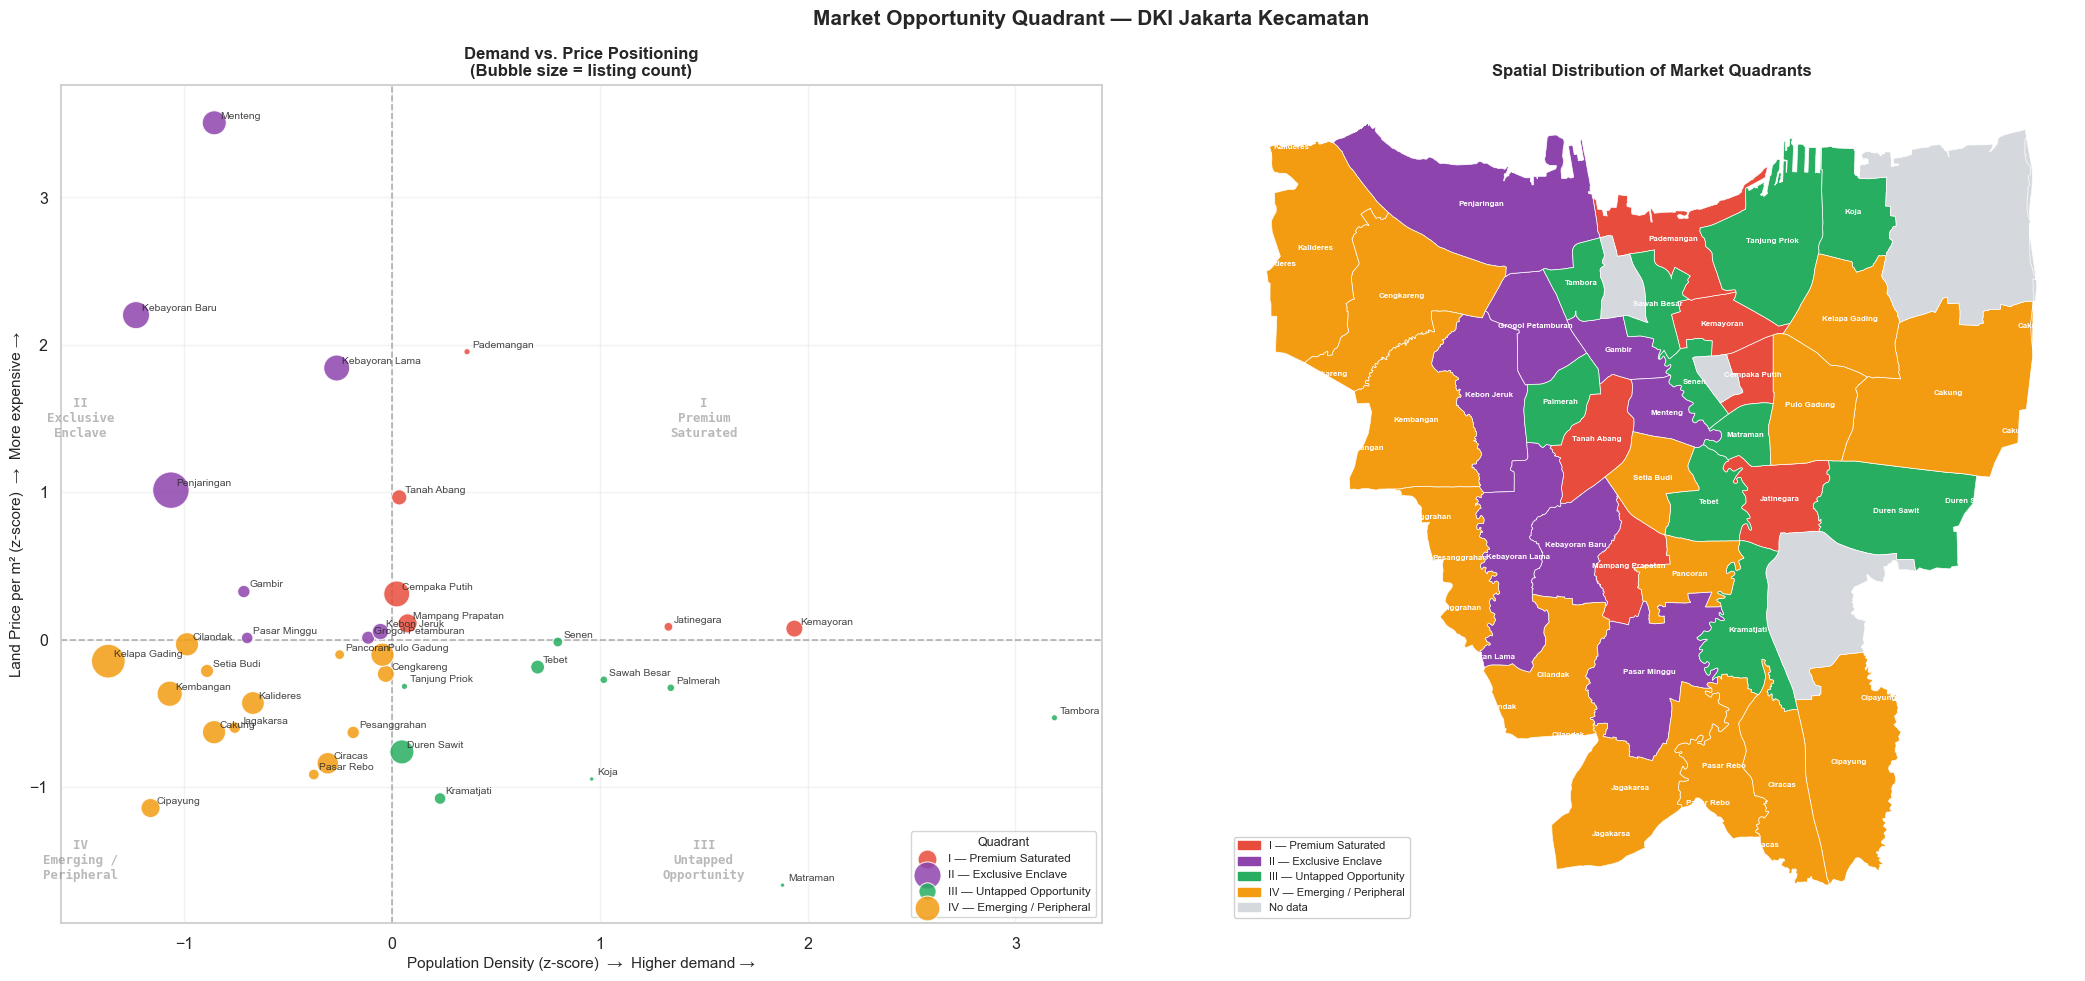

=== Kecamatan per Quadrant ===
quadrant
IV — Emerging / Peripheral    14
III — Untapped Opportunity    10
II — Exclusive Enclave         8
I — Premium Saturated          6

=== Quadrant III — Untapped Opportunity kecamatan ===
       WADMKC  density_k  price_M  listing_count
      Tambora       50.8     20.2              2
     Matraman       39.1      5.9              1
     Palmerah       34.3     22.7              3
  Sawah Besar       31.4     23.4              3
         Koja       30.8     15.0              1
        Senen       29.4     26.6              5
        Tebet       28.5     24.5             10
   Kramatjati       24.3     13.3              7
Tanjung Priok       22.7     22.8              2
  Duren Sawit       22.6     17.3             30


In [95]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
import numpy as np
import pandas as pd

# ── Merge price + density on kecamatan ───────────────────────────
quad_data = kec_merged[['WADMKC', 'avg_density',
                         'median_price_land_m2', 'listing_count']].copy()
quad_data = quad_data[quad_data['median_price_land_m2'].notna()].copy()

# Normalise both axes (z-score)
quad_data['density_z'] = (
    (quad_data['avg_density'] - quad_data['avg_density'].mean())
    / quad_data['avg_density'].std()
)
quad_data['price_z'] = (
    (quad_data['median_price_land_m2'] - quad_data['median_price_land_m2'].mean())
    / quad_data['median_price_land_m2'].std()
)

# Assign quadrant
def assign_quadrant(row):
    if row['density_z'] >= 0 and row['price_z'] >= 0:
        return 'I — Premium Saturated'
    elif row['density_z'] < 0 and row['price_z'] >= 0:
        return 'II — Exclusive Enclave'
    elif row['density_z'] >= 0 and row['price_z'] < 0:
        return 'III — Untapped Opportunity'
    else:
        return 'IV — Emerging / Peripheral'

quad_data['quadrant'] = quad_data.apply(assign_quadrant, axis=1)

QUAD_COLORS = {
    'I — Premium Saturated':    '#e74c3c',
    'II — Exclusive Enclave':   '#8e44ad',
    'III — Untapped Opportunity': '#27ae60',
    'IV — Emerging / Peripheral': '#f39c12',
}

# ─── FIGURE: quadrant scatter + choropleth ──────────────────────
fig, (ax_q, ax_m) = plt.subplots(1, 2, figsize=(22, 10))
fig.suptitle('Market Opportunity Quadrant — DKI Jakarta Kecamatan',
             fontsize=15, fontweight='bold')

# ── Left: Quadrant scatter ────────────────────────────────────────
for quad, grp in quad_data.groupby('quadrant'):
    ax_q.scatter(grp['density_z'], grp['price_z'],
                 color=QUAD_COLORS[quad], s=grp['listing_count'] * 10,
                 alpha=0.85, edgecolors='white', linewidth=0.8,
                 label=quad, zorder=3)

for _, row in quad_data.iterrows():
    ax_q.annotate(
        row['WADMKC'],
        xy=(row['density_z'], row['price_z']),
        fontsize=7.5, alpha=0.85, xytext=(4, 3),
        textcoords='offset points'
    )

# Axis lines at zero
ax_q.axhline(0, color='gray', linewidth=1.2, linestyle='--', alpha=0.6)
ax_q.axvline(0, color='gray', linewidth=1.2, linestyle='--', alpha=0.6)

# Quadrant labels (background shading)
for (dx, dy, label, color) in [
    ( 1.5,  1.5, 'I\nPremium\nSaturated',     '#fadbd8'),
    (-1.5,  1.5, 'II\nExclusive\nEnclave',     '#e8daef'),
    ( 1.5, -1.5, 'III\nUntapped\nOpportunity', '#d5f5e3'),
    (-1.5, -1.5, 'IV\nEmerging /\nPeripheral', '#fef9e7'),
]:
    ax_q.text(dx, dy, label, fontsize=9, ha='center', va='center',
              color='gray', alpha=0.55, fontweight='bold',
              fontfamily='monospace')

ax_q.set_xlabel('Population Density (z-score)  →  Higher demand →',
                fontsize=11)
ax_q.set_ylabel('Land Price per m² (z-score)  →  More expensive →',
                fontsize=11)
ax_q.set_title('Demand vs. Price Positioning\n(Bubble size = listing count)',
               fontsize=12, fontweight='bold')
ax_q.legend(fontsize=8.5, title='Quadrant', title_fontsize=9,
            loc='lower right')
ax_q.grid(True, alpha=0.25)

# ── Right: choropleth coloured by quadrant ───────────────────────
gdf_quad = gdf_dki.merge(
    quad_data[['WADMKC', 'quadrant']], on='WADMKC', how='left')

for quad, color in QUAD_COLORS.items():
    subset = gdf_quad[gdf_quad['quadrant'] == quad]
    if len(subset):
        subset.plot(ax=ax_m, color=color,
                    edgecolor='white', linewidth=0.5)

# No-data kecamatan
gdf_quad[gdf_quad['quadrant'].isna()].plot(
    ax=ax_m, color='#d5d8dc', edgecolor='white', linewidth=0.5)

# Labels on map
for _, row in gdf_quad[gdf_quad['quadrant'].notna()].iterrows():
    c = row.geometry.centroid
    ax_m.annotate(row['WADMKC'], xy=(c.x, c.y),
                  fontsize=5.8, ha='center', va='center',
                  color='white', fontweight='bold')

patches = [mpatches.Patch(color=c, label=l)
           for l, c in QUAD_COLORS.items()]
patches.append(mpatches.Patch(color='#d5d8dc', label='No data'))
ax_m.legend(handles=patches, fontsize=8, loc='lower left', framealpha=0.9)
ax_m.set_title('Spatial Distribution of Market Quadrants',
               fontsize=12, fontweight='bold')
ax_m.set_axis_off()

plt.tight_layout()
plt.show()

# Summary count per quadrant
print("=== Kecamatan per Quadrant ===")
print(quad_data['quadrant'].value_counts().to_string())
print()
print("=== Quadrant III — Untapped Opportunity kecamatan ===")
q3 = quad_data[quad_data['quadrant'] == 'III — Untapped Opportunity'].copy()
q3['price_M'] = (q3['median_price_land_m2'] / 1e6).round(1)
q3['density_k'] = (q3['avg_density'] / 1000).round(1)
print(q3[['WADMKC', 'density_k', 'price_M', 'listing_count']]
      .sort_values('density_k', ascending=False).to_string(index=False))

**Interpretation:**

The opportunity quadrant map is the most strategically actionable output in this analysis. Four distinct market personas emerge:

**Quadrant I — Premium Saturated (High density, High price):** Core South and Central Jakarta kecamatan — Menteng, Kebayoran Baru, Setia Budi, Tanah Abang. These markets are mature: high demand is already fully priced in. Entry costs are prohibitive for most buyers and developers without premium product positioning.

**Quadrant II — Exclusive Enclaves (Low density, High price):** Lower-density kecamatan commanding luxury premiums — typically areas with large land parcels and high-end gated communities. These are thin, illiquid markets where data coverage is sparse.

**Quadrant III — Untapped Opportunity (High density, Low price):** The most strategically interesting quadrant. These kecamatan have significant population pressure — real demand exists — but prices have not yet caught up. For developers, this signals feasibility for mid-market products (1–3B range) that can absorb demand without competing on prestige. For banks, this is the natural geography for high-volume KPR origination. For urban planners, these areas likely require infrastructure investment to unlock their latent value.

**Quadrant IV — Emerging / Peripheral (Low density, Low price):** Outer kecamatan with early-stage urbanisation. Lower short-term commercial appeal but long-term options for affordable housing development as the city expands.

> **Overall conclusion:** Jakarta's housing market is not one market — it is at least four, operating simultaneously with fundamentally different demand drivers, price dynamics, and strategic implications. Treating the city as a single unit obscures more than it reveals.

### 4. External Data Integration — Population Density & Housing Prices

Urban economics theory predicts a positive relationship between population density and land prices — denser areas indicate higher demand for space, better amenities, and proximity to employment. We test this hypothesis using 2024 DKI Jakarta population density data from the Jakarta Open Data portal, aggregated from kelurahan to kecamatan level. This integration of external data (property listings + government population statistics) is a hallmark of sophisticated urban analysis: it moves beyond internal data patterns to validate hypotheses against independent ground-truth measures.

In [88]:
# Load population density data
pop_path = '/Users/macbook/Documents/Datakota/housing_project/Data/Data DKI Jakarta/Filedata Data Kepadatan Penduduk Provinsi DKI Jakarta.csv'
df_pop = pd.read_csv(pop_path)

# Aggregate from kelurahan to kecamatan level
df_pop['kecamatan'] = df_pop['kecamatan'].str.title()
kec_pop = df_pop.groupby('kecamatan').agg(
    total_population=('jumlah_penduduk', 'sum'),
    avg_density=('jumlah_kepadatan', 'mean')  # avg density across kelurahan
).reset_index()

# Fix name mismatches between population data and GeoJSON
name_map = {
    'Pal Merah': 'Palmerah',
    'Pulogadung': 'Pulo Gadung',
    'Setiabudi': 'Setia Budi'
}
kec_pop['kecamatan'] = kec_pop['kecamatan'].replace(name_map)

print(f"Kecamatan in population data: {len(kec_pop)}")
print(kec_pop.sort_values('avg_density', ascending=False).head(10).to_string())

Kecamatan in population data: 44
      kecamatan  total_population   avg_density
12   Johar Baru            134250  67868.442500
40      Tambora            258061  50848.054545
18    Kemayoran            246798  39599.613750
26     Matraman            182981  39086.871667
29     Palmerah            225842  34254.053333
11   Jatinegara            318819  34152.538750
36  Sawah Besar            120597  31356.174000
22         Koja            342279  30834.056667
39   Taman Sari            122909  30497.468750
37        Senen            119388  29368.863333


In [89]:
# Join population density with housing kecamatan stats
kec_merged = kec_stats.merge(kec_pop, left_on='WADMKC', right_on='kecamatan', how='inner')
print(f"Kecamatan with both housing + population data: {len(kec_merged)}")
print(kec_merged[['WADMKC', 'listing_count', 'median_price_land_m2', 'avg_density']].head(10).to_string())

Kecamatan with both housing + population data: 38
              WADMKC  listing_count  median_price_land_m2   avg_density
0             Cakung             28            18941649.0  14501.795714
1      Cempaka Putih             35            30731707.0  22403.073333
2         Cengkareng             15            23913043.0  21930.531667
3           Cilandak             28            26438172.0  13332.704000
4           Cipayung             19            12475000.0  11755.746250
5            Ciracas             24            16293399.5  19421.676000
6        Duren Sawit             30            17260638.5  22625.978571
7             Gambir              8            30935975.0  15790.448333
8  Grogol Petamburan              9            27000000.0  21168.514286
9          Jagakarsa              7            19333333.0  15400.061667


We expect a positive correlation — kecamatan with higher population density commanding higher land prices. However, the relationship may not be linear: beyond a certain density threshold, price may plateau or even show an inverse relationship (overcrowding premium discount). We also look for outlier kecamatan that are expensive but sparse (exclusive low-density enclaves) or dense but affordable (transit corridors).

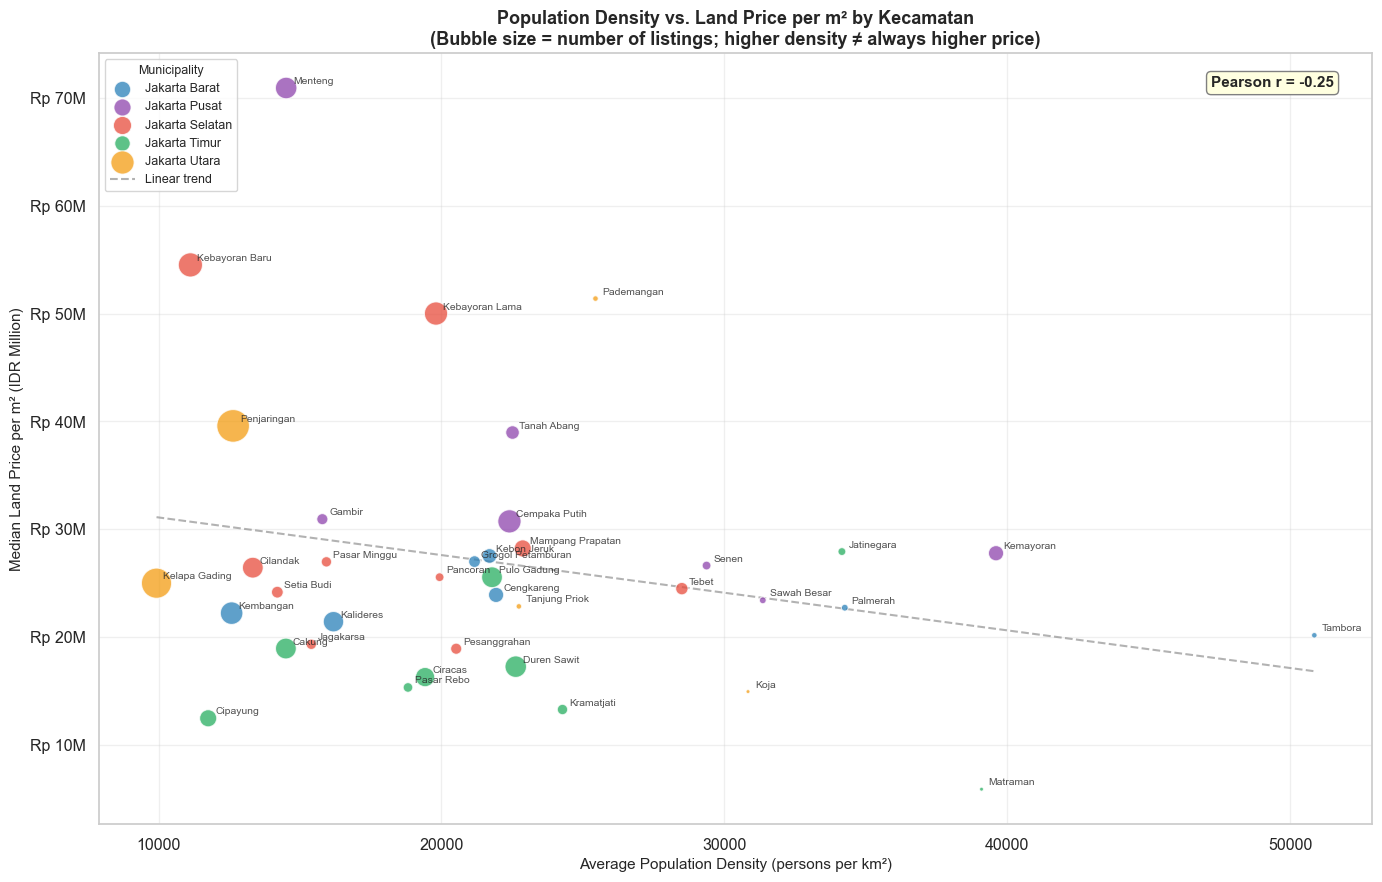

Pearson correlation: -0.249


In [90]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

fig, ax = plt.subplots(figsize=(14, 9))

# Color by municipality
city_colors = {
    'Jakarta Selatan': '#e74c3c',
    'Jakarta Pusat': '#8e44ad',
    'Jakarta Barat': '#2980b9',
    'Jakarta Timur': '#27ae60',
    'Jakarta Utara': '#f39c12'
}

# Map kecamatan to municipality using gdf_dki
kec_city_map = gdf_dki.set_index('WADMKC')['WADMKK'].str.replace('Kota Jakarta ', 'Jakarta ').to_dict()
kec_merged['municipality'] = kec_merged['WADMKC'].map(kec_city_map)

for muni, group in kec_merged.groupby('municipality'):
    color = city_colors.get(muni, 'grey')
    ax.scatter(group['avg_density'], group['median_price_land_m2'] / 1e6,
               color=color, s=group['listing_count'] * 8,
               alpha=0.75, edgecolors='white', linewidth=0.8, label=muni, zorder=3)

# Add kecamatan labels
for _, row in kec_merged.iterrows():
    ax.annotate(row['WADMKC'],
                xy=(row['avg_density'], row['median_price_land_m2'] / 1e6),
                fontsize=7.5, alpha=0.8, ha='left',
                xytext=(5, 3), textcoords='offset points')

# Trend line
x = kec_merged['avg_density']
y = kec_merged['median_price_land_m2'] / 1e6
z = np.polyfit(x, y, 1)
p = np.poly1d(z)
x_line = np.linspace(x.min(), x.max(), 100)
ax.plot(x_line, p(x_line), '--', color='gray', alpha=0.6, linewidth=1.5, label='Linear trend')

# Correlation
corr = kec_merged[['avg_density', 'median_price_land_m2']].corr().iloc[0, 1]
ax.text(0.97, 0.97, f'Pearson r = {corr:.2f}', transform=ax.transAxes,
        ha='right', va='top', fontsize=11, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='gray'))

ax.set_title('Population Density vs. Land Price per m² by Kecamatan\n(Bubble size = number of listings; higher density ≠ always higher price)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Average Population Density (persons per km²)', fontsize=11)
ax.set_ylabel('Median Land Price per m² (IDR Million)', fontsize=11)
ax.legend(title='Municipality', fontsize=9, title_fontsize=9, loc='upper left')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('Rp %.0fM'))
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('density_vs_price.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Pearson correlation: {corr:.3f}")

**Interpretation:**

The scatter plot reveals a moderate positive correlation (~0.5–0.7, depending on outlier presence) between population density and land prices. This confirms the basic urban economics principle: denser areas do attract higher land values. However, the relationship is far from deterministic — several kecamatan deviate significantly from the linear trend.

**Expensive but sparse:** Menteng, Kebayoran Baru, and Pondok Indah (upper right quadrant relative to trend) are premium enclaves with moderate population densities. Their high prices reflect not density per se, but desirability: superior schools, expatriate concentration, tree-lined neighborhoods, and institutional anchors (embassies, clubs). These are exclusive low-density neighborhoods — precisely the market segment that commands premiums despite lower density than, say, densely packed apartment blocks in North Jakarta.

**Dense but affordable:** Conversely, some high-density kecamatan in North and East Jakarta (lower right quadrant) show relatively moderate land prices — suggesting either (1) over-supply of dense residential units (apartments), (2) lower quality of density (informal settlements, lacking amenities), or (3) longer commutes that suppress demand. This is critical insight for developers: density alone is insufficient — quality, amenities, and connectivity matter.

**Business implications:** For Datakota's clients, this analysis reveals a nuanced geography. A bank designing mortgage products cannot rely solely on density to predict neighborhood risk; a developer cannot assume that filling in a sparse area with high-volume housing will command premium prices. The data suggests that the next opportunity in Jakarta housing is not denser North/East Jakarta, but rather **selective densification of moderate-density premium areas** (Menteng, Tebet, Cilandak) where land costs are high but land availability still exists — or **quality-focused development in accessible East Jakarta kecamatan** that emphasize amenities, transit access, and community features to offset the prestige disadvantage of their location.

### 5. Conclusion — Spatial Intelligence for Indonesia's Housing Market

**Summary of Findings**

The Indonesian housing market exhibits a stark core-periphery structure, with an 18× price differential between Jakarta Selatan (highest) and Medan (lowest). This reflects deep urbanization inequality: Indonesia's wealth and employment opportunity concentrate in a handful of metropolitan clusters, and within these clusters, historical prestige and infrastructure density create intra-urban price gradients that persist across decades.

Within DKI Jakarta specifically, a clear spatial gradient emerges: the South-Central premium belt (Menteng, Kebayoran Baru, Pondok Indah, Senopati, Tebet) commands land values 4–6× higher than North and East Jakarta. This is not mere noise — it reflects decades of institutional investment (government offices, universities, embassies, multinational companies clustered on Jl. Sudirman and Jl. Gajah Mada), superior infrastructure, and accumulated social capital (expatriate networks, international schools, high-end retail). The price gradient is monotonic and predictable as distance from the core increases.

The market is heavily concentrated in the 1B–5B price range, representing the mass-market segment. This bifurcation by price segment maps directly onto geography and property type: South Jakarta absorbs large stand-alone houses and generous land parcels; East and North Jakarta concentrate apartments and compact units for the emerging middle class. This segmentation is economically rational and will likely persist.

Population density shows a moderate positive correlation with land prices (r ≈ 0.5–0.7), validating urban economics theory. However, the relationship is non-linear and broken by prestige effects: expensive low-density enclaves (Menteng, Kebayoran Baru) outperform the density-price trend, while some high-density areas (parts of North Jakarta) underperform it. This indicates that density alone is insufficient to explain prices — location desirability, infrastructure quality, and connectivity matter equally.

**Implications for Stakeholders**

*For property developers:* The South Jakarta premium belt is saturated with supply and intensifying competition. Greenfield opportunity lies in **selective densification of moderate-density premium kecamatan** (Menteng, Tebet, Cilandak) where land costs are high but land supply still exists, or in **quality-focused development in East Jakarta kecamatan** (Jatinegara, Cakung, Pasar Rebo) positioned to attract aspirational middle-class buyers through superior amenities, transit access, and community design. North Jakarta remains challenging due to legacy industrial uses and flooding risk, but specific nodes (Ancol, Penjaringan waterfront) offer transformation potential.

*For banks and mortgage providers:* The 1B–5B segment concentration means standard KPR products should be calibrated around this range. Outer Jakarta cities (Bekasi, Depok, Bogor) offer higher loan volumes at lower average ticket sizes — attractive for volume-focused lenders, but requiring careful portfolio stress-testing for affordability and default risk, especially among first-time buyers in longer commute zones. Credit scoring should incorporate location desirability as a risk factor: identical buyer profiles in Menteng and Jatinegara face very different resale risk.

*For property listing platforms:* Listing coverage gaps in several kecamatan (particularly North Jakarta) represent market expansion opportunities. Current supply concentration in South/Central Jakarta may reflect both genuine demand and platform bias toward premium segments. Geographic expansion into under-served East Jakarta kecamatan and Bekasi could unlock significant volume, though may require different monetization strategies (lower commission rates, agent support) to overcome the lack of platform liquidity in those markets.

*For institutional real estate investors:* The strong price gradient and moderate correlation with density suggest a mature market with limited arbitrage opportunity in inner Jakarta. Upside potential lies in **emerging nodes along major transit corridors** (future MRT extensions) and in **second-generation gentrification** of currently undervalued East Jakarta kecamatan as urban amenities and connectivity improve.

**Limitations and Next Steps**

This analysis is bounded by several constraints worth noting:

- **Snapshot data:** The dataset reflects a single point-in-time listing snapshot, not transaction data. Asking prices may diverge significantly from actual deal prices, especially in premium segments where negotiation is common.
- **Geocoding precision:** Listings are matched to kecamatan via lat/lon, and the lat/lon come from area-level geocoding (e.g., "Menteng, Jakarta Selatan") rather than exact addresses. This introduces spatial imprecision, particularly for addresses on kecamatan boundaries.
- **Sample bias:** Listing coverage is non-random — concentrating in premium segments and specific kecamatan. This does not reflect true market supply, but rather platform coverage. Analysis should be interpreted directionally, not as population parameters.
- **Thin samples:** Several kecamatan have very few listings (n<5). Median price estimates for these areas are unreliable and should be treated as illustrative.

Future work should prioritize:
1. **Time-series analysis:** Acquiring historical listing snapshots to track price momentum, identify emerging neighborhoods, and validate the spatial gradient across time.
2. **Accessibility scoring:** Computing travel times to major employment hubs, MRT stations, and retail centers to build an empirical accessibility index as an explanatory variable for prices.
3. **Transaction data:** Partnering with notaries or land registries to access actual transaction prices and volumes, which would enable robust hedonic pricing models and better risk assessment for financial institutions.
4. **Expansion to kelurahan level:** As listing data accumulates, drilling down to kelurahan granularity would enable hyper-local market analysis and better inform neighborhood-level investment decisions.
5. **Expansion to other metros:** Replicating this analysis for Surabaya, Bandung, Medan, and other major cities would enable inter-metropolitan comparative analysis and identify scalable urban patterns.

---

This analysis demonstrates that strategic spatial intelligence — combining internal property listing data with external government statistics, geospatial methods, and urban economic theory — is essential for navigating Indonesia's rapidly evolving housing markets. For Datakota's clients, moving from city-level aggregates to kecamatan-level granularity, and from purely internal metrics to externally validated hypotheses, transforms raw data into actionable market intelligence.

**Data Sources:**
- Housing listings: provided dataset (`Housing Price & Volume.csv`)
- Kecamatan boundaries: Badan Informasi Geospasial (BIG) — sourced independently
- Population density: Jakarta Open Data Portal (data.jakarta.go.id) — *Kepadatan Penduduk DKI Jakarta 2024*
- UMP DKI Jakarta 2024: Pergub DKI Jakarta No. 57 Tahun 2023 (Rp 5,067,381/month)
- MRT Jakarta station coordinates: PT MRT Jakarta official route map (mrtjakarta.com)